<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Lecture 4

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

**What:** A lecture of the "3dasm" course

**Where:** This notebook comes from this [repository](https://github.com/bessagroup/3dasm_course)

**Reference for entire course:** Murphy, Kevin P. *Probabilistic machine learning: an introduction*. MIT press, 2022. Available online [here](https://probml.github.io/pml-book/book1.html)

**How:** We try to follow Murphy's book closely, but the sequence of Chapters and Sections is different. The intention is to use notebooks as an introduction to the topic and Murphy's book as a resource.
* If working offline: Go through this notebook and read the book.
* If attending class in person: listen to me (!) but also go through the notebook in your laptop at the same time. Read the book.
* If attending lectures remotely: listen to me (!) via Zoom and (ideally) use two screens where you have the notebook open in 1 screen and you see the lectures on the other. Read the book.

**Optional reference (the "bible" by the "bishop"... pun intended 😆) :** Bishop, Christopher M. *Pattern recognition and machine learning*. Springer Verlag, 2006.

**References/resources to create this notebook:**
* [Car figure](https://korkortonline.se/en/theory/reaction-braking-stopping/)
* [Correlation coefficient figure](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)
* For the wireframe plot of joint pdf: [Mathematics for Machine Learning book](https://mml-book.github.io/) and corresponding [jupyter notebook for Chapter 6](https://github.com/vbartle/MML-Companion)

Apologies in advance if I missed some reference used in this notebook. Please contact me if that is the case, and I will gladly include it here.

## **OPTION 1**. Run this notebook **locally in your computer**:
1. Confirm that you have the '3dasm' mamba (or conda) environment (see Lecture 1).
2. Go to the 3dasm_course folder in your computer and pull the last updates of the [repository](https://github.com/bessagroup/3dasm_course):
```
git pull
```
    - Note: if you can't pull the repo due to conflicts (and you can't handle these conflicts), use this command (with **caution**!) and your repo becomes the same as the one online:
```
git reset --hard origin/main
```
3. Open command window and load jupyter notebook (it will open in your internet browser):
```
jupyter notebook
```
5. Open notebook of this Lecture and choose the '3dasm' kernel.

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook for this Lecture.

In [1]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!
from IPython.display import display, Math # to print with Latex math

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
#plt.style.use("seaborn") # style for plotting that comes from seaborn
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides
plt.rcParams['axes.grid'] = False # to avoid a warning message when plotting

## Outline for today

* Bayes' rule (where we stopped last class)
* Probability: multivariate models
    - The multivariate Gaussian: joint pdf, conditional pdf and marginal pdf
    - Covariance and covariance matrix

**Reading material**: This notebook (+ Bishop's book Section 2.3)

## Remember the amazing Bayes' rule

Bayes’ rule: a formula for computing the probability distribution over possible values of an unknown (or hidden) quantity $z$ given some observed data $y$:

$$
p(z|y) = \frac{p(y|z) p(z)}{p(y)}
$$

Bayes' rule follows automatically from the identity: $p(z|y) p(y) = p(y|z) p(z) = p(y,z) = p(z,y)$

## Bayes' rule

The pdfs we have been discussing in this lecture are what enable us to create ML models via the Bayes' rule when we apply it on **observed data** $\mathcal{D}_y$:

$$
{\color{green}{p(z|y=\mathcal{D}_y)}} = \frac{ \color{blue}{p(y=\mathcal{D}_y|z)}{\color{red}{p(z)}} } {p(y=\mathcal{D}_y)}
$$

* ${\color{red}{p(z)}}$ is the **prior** distribution: this term represents what we know (or what we believe we know!) about possible values of the unknown (hidden) <a title="random variable">rv</a> $z$ before we see any data.

## Bayes' rule

The pdfs we have been discussing in this lecture are what enable us to create ML models via the Bayes' rule when we apply it on **observed data** $\mathcal{D}_y$:

$$
{\color{green}{p(z|y=\mathcal{D}_y)}} = \frac{ \color{blue}{p(y=\mathcal{D}_y|z)} {\color{red}{p(z)}} } {p(y=\mathcal{D}_y)}
$$

* ${\color{blue}{p(y | z)}}$ is the **observation** distribution (not yet the likelihood!): represents the distribution over the possible outcomes $y$ we expect to see given a particular hidden variable $z$.
    - When we evaluate the observation distribution $p(y | z)$ at a point corresponding to the actual observations, $y=\mathcal{D}_y$, we get the function $p(y=\mathcal{D}_y|z)$:
        * ${\color{blue}p(y=\mathcal{D}_y|z)}$ is the **likelihood** function: it is a function of $z$, since $y$ is *fixed* to the observations $\mathcal{D}_y$, but **it is not a probability distribution** (it does not sum to one).

## Bayes' rule

The pdfs we have been discussing in this lecture are what enable us to create ML models via the Bayes' rule when we apply it on **observed data** $\mathcal{D}_y$:

$$
{\color{green}{p(z|y=\mathcal{D}_y)}} = \frac{ \color{blue}{p(y=\mathcal{D}_y|z)}{\color{red}{p(z)}} } {p(y=\mathcal{D}_y)}
$$

* $p(y=\mathcal{D}_y)$ is the **marginal likelihood**, which is obtained by *marginalizing* over the unknown $z$.

## Bayes' rule

The pdfs we have been discussing in this lecture are what enable us to create ML models via the Bayes' rule when we apply it on **observed data** $\mathcal{D}_y$:

$$
{\color{green}{p(z|y=\mathcal{D}_y)}} = \frac{ \color{blue}{p(y=\mathcal{D}_y|z)}{\color{red}{p(z)}} } {p(y=\mathcal{D}_y)}
$$

* ${\color{green}{p(z|y=\mathcal{D}_y)}}$ is the **posterior**, which represents our *belief state* about the possible values of the unknown $z$.

### A note about the term "distribution"

The term distribution can mean two things:
1. For **continuous** <a title="random variables">rv's</a>, the term *distribution* means *probability density function* (<a title="probability density function">pdf</a>).

2. For **discrete** <a title="random variables">rv's</a> the term *distribution* means *probability mass function* (<a title="probability mass function">pmf</a>), as we will see later in the course.

We won't talk about categorical distributions or <a title="probability mass functions">pmf's</a> for a while. So, for now, when you see the term *distribution* it is the same as saying <a title="probability density function">pdf</a>.

## Summary of Bayes' rule

$$
{\color{green}{p(z|y=\mathcal{D}_y)}} = \frac{ {\color{blue}{p(y=\mathcal{D}_y|z)}} {\color{red}{p(z)}} } {p(y=\mathcal{D}_y)} = \frac{ {\color{magenta}{p(y=\mathcal{D}_y, z)}} } {p(y=\mathcal{D}_y)}
$$

* ${\color{red}{p(z)}}$ is the **prior** distribution
* ${\color{blue}{p(y=\mathcal{D}_y|z)}}$ is the **likelihood** function
* ${\color{magenta}{p(y=\mathcal{D}_y, z)}}$ is the **joint likelihood** (product of likelihood function with prior distribution)
* $p(y=\mathcal{D}_y)$ is the **marginal likelihood**
* ${\color{green}{p(z|y=\mathcal{D}_y)}}$ is the **posterior**

We can write Bayes' rule as <font color='green'>posterior</font> $\propto$ <font color='blue'>likelihood</font> $\times$ <font color='red'>prior </font>, where we are ignoring the denominator $p(y=\mathcal{D}_y)$ because it is just a **constant** independent of the hidden variable $z$.

## Diving deeper into the joint pdf

Later we will dedicate a lot of effort to using Bayes' rule to update a distribution over unknown values of
some quantity of interest, given relevant observed data $\mathcal{D}_y$.

This is what is called *Bayesian inference* (a.k.a. *posterior inference*).

* But before we do that, we need to understand very well multivariate pdfs.
    - In particular, let's focus on the most important one: the **multivariate Gaussian**

## Multivariate Gaussian <a title="probability density function">pdf</a> (a.k.a. <a title="Multivariate normal">MVN</a> distribution)

The multivariate Gaussian <a title="probability density function">pdf</a> of a $D$-dimensional vector $\mathbf{x}$ is given by,

$$
\begin{align}
p(\mathbf{x}|\boldsymbol{\mu},\boldsymbol{\Sigma}) & = \frac{e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}}{\sqrt{(2\pi)^D |\boldsymbol{\Sigma}|}} \\
& = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right]
\end{align}
$$

where $\boldsymbol{\mu}=\mathbb{E}[\mathbf{x}]\in \mathbb{R}^D$ is the mean vector, and $\boldsymbol{\Sigma}= \text{Cov}[\mathbf{x}]$ is the $D\times D$ **covariance matrix**. 

### Covariance matrix

The covariance matrix is a natural generalization of the variance (Lecture 1) for the multivariate case!

$$
\begin{align}
\boldsymbol{\Sigma} = \text{Cov}[\mathbf{x}] &= \mathbb{E}\left[(\mathbf{x}-\mathbb{E}[\mathbf{x}])(\mathbf{x}-\mathbb{E}[\mathbf{x}])^T \right] \\
 &= \begin{bmatrix}
\mathbb{V}[x_1] & \text{Cov}[x_1,x_2] & \cdots & \text{Cov}[x_1, x_D] \\
\text{Cov}[x_2,x_1] & \mathbb{V}[x_2] & \cdots & \text{Cov}[x_2, x_D] \\
\vdots          & \vdots & \ddots & \vdots \\
\text{Cov}[x_D,x_1] & \text{Cov}[x_D,x_2] & \cdots & \mathbb{V}[x_D] \\
\end{bmatrix}
\end{align}
$$

where $\text{Cov}[x_i,x_j] = \mathbb{E}\left[(x_i-\mathbb{E}[x_i])(x_j-\mathbb{E}[x_j])\right] = \mathbb{E}[x_i x_j] - \mathbb{E}[x_i]\mathbb{E}[x_j]$

Also note that $\mathbb{V}[x_i]=\text{Cov}[x_i,x_i]$.

#### Notes about covariance and normalized covariance (correlation coefficient)

The covariance between two rv's $y$ and $z$ measures the degree to which $y$ and $z$ are **linearly** related.

Covariances can be between negative and positive infinity.

Sometimes it is more convenient to work with a normalized measure, with a finite lower and upper bound. The (Pearson) **correlation coefficient** between $y$ and $z$ is defined as

$$
\rho = \text{corr}[y,z] = \frac{\text{Cov}[y,z]}{\sqrt{\mathbb{V}[y]\mathbb{V}[z]}}
$$

Covariance and correlation coefficient measure the same relationship.

#### Note about normalized covariance (correlation coefficient)

Several sets of $(y_i, z_i)$ points, with the correlation coefficient of $y$ and $z$ for each set.

<img src="../figures/Correlation_examples2.svg" title="Correlation coefficient" width="65%" align="right">
Top row: $\text{corr}[y,z]$ reflects the noisiness and direction of a linear relationship.

Middle row: $\text{corr}[y,z]$ **does not** reflect the slope of that relationship

Bottom row: $\text{corr}[y,z]$ **does not** reflect many aspects of nonlinear relationships.

(Additional note: the figure in the center has a slope of 0 but in that case the correlation coefficient is undefined because the variance of $z$ is zero.)

## Understanding the MVN pdf (a common joint pdf)

$$
\begin{align}
p(\mathbf{x}|\boldsymbol{\mu},\boldsymbol{\Sigma}) & = \frac{e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\mu)}}{\sqrt{(2\pi)^D |\boldsymbol{\Sigma}|}} \\
& = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right]
\end{align}
$$

where $\boldsymbol{\mu}=\mathbb{E}[\mathbf{x}]\in \mathbb{R}^D$ is the mean vector, and $\boldsymbol{\Sigma}= \text{Cov}[\mathbf{x}]$ is the $D\times D$ **covariance matrix**. 

* Multivariate Gaussian pdf's are very important in ML and Statistics.

* Let's discover their properties by working out some examples.

### Homework 2 (Exercise 5): MVN from independent Gaussian rv's

Consider two **independent** rv's $x_1$ and $x_2$ where each of them is a univariate Gaussian pdf:

$$
x_1 = \mathcal{N}(x_1|\mu_{x_1}, \sigma_{x_1}^2)
$$

$$
x_2 = \mathcal{N}(x_2|\mu_{x_2}, \sigma_{x_2}^2)
$$

where $\mu_{x_1}=10$, $\sigma_{x_1}^2=5^2$, $\mu_{x_2}=0.5$ and $\sigma_{x_2}^2=2^2$.

Answer the following questions:

1. What is the joint pdf $p(x_1, x_2)$?

2. Calculate the covariance matrix for $\mathbf{x}=\begin{bmatrix}x_1\\x_2\end{bmatrix}$.

The next slide plots the solution of the joint pdf... (But do your homework!)

In [2]:
# This code is hidden during presentation (shown as notes).
from scipy.stats import norm # import from scipy.stats the normal distribution
from matplotlib.gridspec import GridSpec # for more control over subplots that have 2D and 3D axes
#from matplotlib import cm 

mu_x1 = 10.0; sigma_x1 = 5; # parameters of p(x1)
mu_x2 = 0.5; sigma_x2 = 2.0 # parameters of p(x2)

# Since x1 and x2 are independent, we don't even need to call multivariate_normal from scipy.stats
N_samples = 300 # number of samples
x1range = np.linspace(-3*sigma_x1+mu_x1, 3*sigma_x1+mu_x1, N_samples) # x1 values for plotting
x2range = np.linspace(-3*sigma_x2+mu_x2, 3*sigma_x2+mu_x2, N_samples) # x2 values for plotting
samples_x1 = norm.rvs(mu_x1, sigma_x1, size=N_samples) # sample from p(x1)
samples_x2 = norm.rvs(mu_x2, sigma_x2, size=N_samples) # sample from p(x2)

# This figure is created such that the histograms seem a projection of the 3D plot
# I used a simple trick of creating a grid of 4x3 subplots and assigning a 3x3 grid to the 3D plot alone
fig_joint_pdf_HW2_ex5 = plt.figure()
gs = GridSpec(4, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf_HW2_ex5 = fig_joint_pdf_HW2_ex5.add_subplot(gs[1:,0:], projection='3d')
ax_joint_pdf_HW2_ex5.set_facecolor('white') # set background for this subplot
x1_grid,x2_grid = np.meshgrid(x1range,x2range) # grid for surface plot
joint_pdf_grid_HW2_ex5 = norm.pdf(x1_grid,mu_x1,sigma_x1)*norm.pdf(x2_grid,mu_x2,sigma_x2) # joint pdf values
ax_joint_pdf_HW2_ex5.plot_wireframe(x1_grid, x2_grid, joint_pdf_grid_HW2_ex5, color = 'grey', alpha=0.5) # surface plot
ax_joint_pdf_HW2_ex5.scatter(samples_x1,samples_x2,np.zeros(N_samples), alpha = .7, s = 10) # samples in the z-y plane
ax_joint_pdf_HW2_ex5.scatter(np.mean(samples_x1), np.mean(samples_x2), marker = "d", c = "r", s=100) # show the mean
ax_joint_pdf_HW2_ex5.set_xlabel(r"$x_1$", fontsize=20)
ax_joint_pdf_HW2_ex5.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_HW2_ex5.set_ylabel(r"$x_2$", fontsize=20)
ax_joint_pdf_HW2_ex5.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_HW2_ex5.set_zlabel(r"$p(x_1,x_2)$", fontsize=20)
ax_joint_pdf_HW2_ex5.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_HW2_ex5.set_xlim3d(-3*sigma_x1+mu_x1,3*sigma_x1+mu_x1) # x1 axis limits
ax_joint_pdf_HW2_ex5.set_ylim3d(-3*sigma_x2+mu_x2,3*sigma_x2+mu_x2) # x2 axis limits

# Remind the histogram and pdf for z
ax_hist_x1_HW2_ex5 = fig_joint_pdf_HW2_ex5.add_subplot(gs[0,2])
ax_hist_x1_HW2_ex5.hist(samples_x1, bins='auto', density=True, label='Histogram')  
ax_hist_x1_HW2_ex5.plot(x1range, norm.pdf(x1range, mu_x1, sigma_x1), 'k--', linewidth = 3, label='$p(x_1)$')
ax_hist_x1_HW2_ex5.set_xlabel("$x_1$", fontsize=20)
ax_hist_x1_HW2_ex5.set_ylabel("probability density", fontsize=20)
ax_hist_x1_HW2_ex5.legend(fontsize=15, loc='upper left');

# Create the histogram and pdf for y|z again (to remind about the scaling)
ax_hist_x2_HW2_ex5 = fig_joint_pdf_HW2_ex5.add_subplot(gs[0,0]) # place it in position [1,0] in the 3x3 grid
ax_hist_x2_HW2_ex5.hist(samples_x2, bins='auto', density=True, label='Histogram')  
ax_hist_x2_HW2_ex5.plot(x2range, norm.pdf(x2range, mu_x2, sigma_x2),
               'k--', linewidth = 3, label='$p(x_2)$')
ax_hist_x2_HW2_ex5.set_xlabel("$x_2$", fontsize=20)
ax_hist_x2_HW2_ex5.set_ylabel("probability density", fontsize=20)
ax_hist_x2_HW2_ex5.legend(fontsize=15, loc='upper left');

# Create figure with specified size but close it so that we open the figure just for presentation
fig_joint_pdf_HW2_ex5.set_size_inches(20, 10) # scale figure to be wider (since there are 2 subplots)
plt.close(fig_joint_pdf_HW2_ex5) # do not plot the figure now. We will show it in a later cell

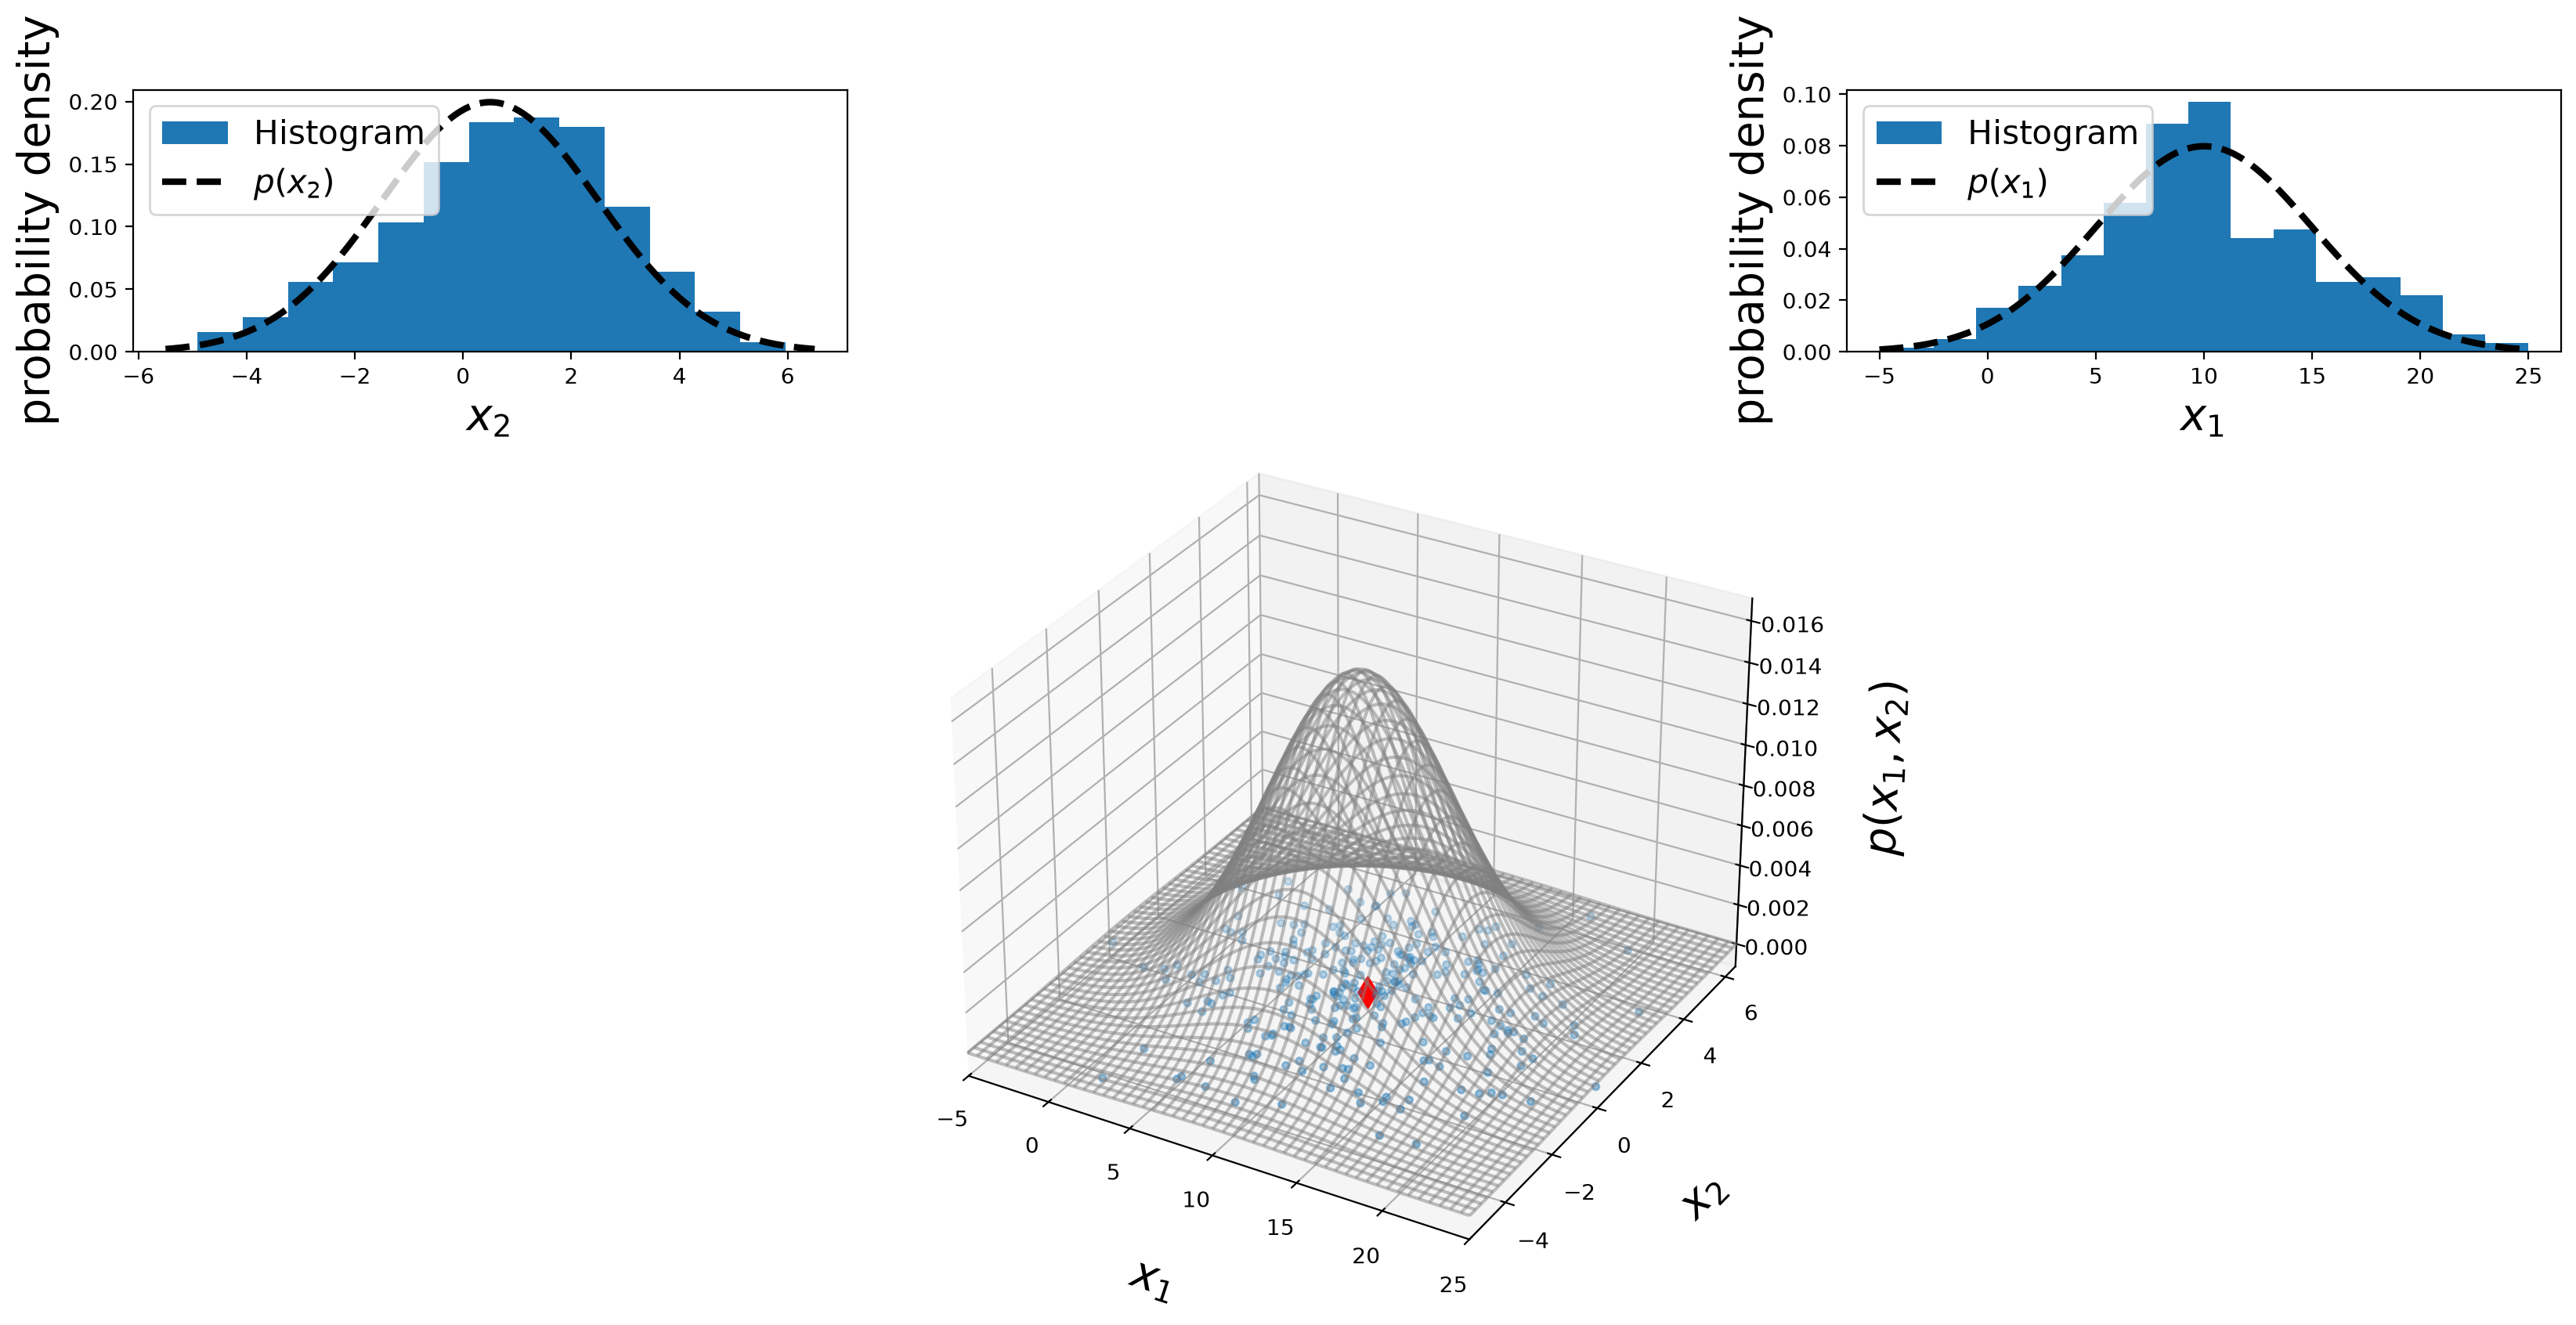

In [3]:
# HIGHLIGHT DIFFERENCE IN MAXIMUM PROBABILITY DENSITIES!!
fig_joint_pdf_HW2_ex5 # The joint pdf results from the multiplication...

In [4]:
#Make a 3D plot
fig_joint_pdf_HW2_ex5_color = plt.figure()
gs = GridSpec(1, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf_HW2_ex5_color_surface = fig_joint_pdf_HW2_ex5_color.add_subplot(gs[0,:2], projection='3d') # use 1x2 grid
ax_joint_pdf_HW2_ex5_color_surface.set_facecolor('white') # set background for this subplot
ax_joint_pdf_HW2_ex5_color_surface.plot_surface(x1_grid, x2_grid, joint_pdf_grid_HW2_ex5,cmap='viridis',linewidth=0)
ax_joint_pdf_HW2_ex5_color_surface.set_xlabel('$x_1$', fontsize=20)
ax_joint_pdf_HW2_ex5_color_surface.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_HW2_ex5_color_surface.set_ylabel('$x_2$', fontsize=20)
ax_joint_pdf_HW2_ex5_color_surface.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_HW2_ex5_color_surface.set_zlabel('probability density of $p(x_1, x_2)$', fontsize=20)
ax_joint_pdf_HW2_ex5_color_surface.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)

# Subplot with the contour of the joint pdf p(y,z)
ax_joint_pdf_HW2_ex5_color_contour2 = fig_joint_pdf_HW2_ex5_color.add_subplot(gs[0,2])
CS = ax_joint_pdf_HW2_ex5_color_contour2.contourf(x1_grid, x2_grid, joint_pdf_grid_HW2_ex5, 50, cmap="viridis")
ax_joint_pdf_HW2_ex5_color_contour2.set_xlabel('$x_1$', fontsize=20)
ax_joint_pdf_HW2_ex5_color_contour2.set_ylabel('$x_2$', fontsize=20)
cbar = fig_joint_pdf_HW2_ex5_color.colorbar(CS) # Make a colorbar for the ContourSet returned by the contourf call.
cbar.ax.set_ylabel('probability density of $p(x_1, x_2)$', fontsize=20)
#ax_MVN_contour2.set_title('Multivariate Normal distribution (MVN)', fontsize=20)

# Create figure with specified size
fig_joint_pdf_HW2_ex5_color.set_size_inches(25, 10)
plt.close(fig_joint_pdf_HW2_ex5_color) # do not plot the figure now. We will show it in a later cell

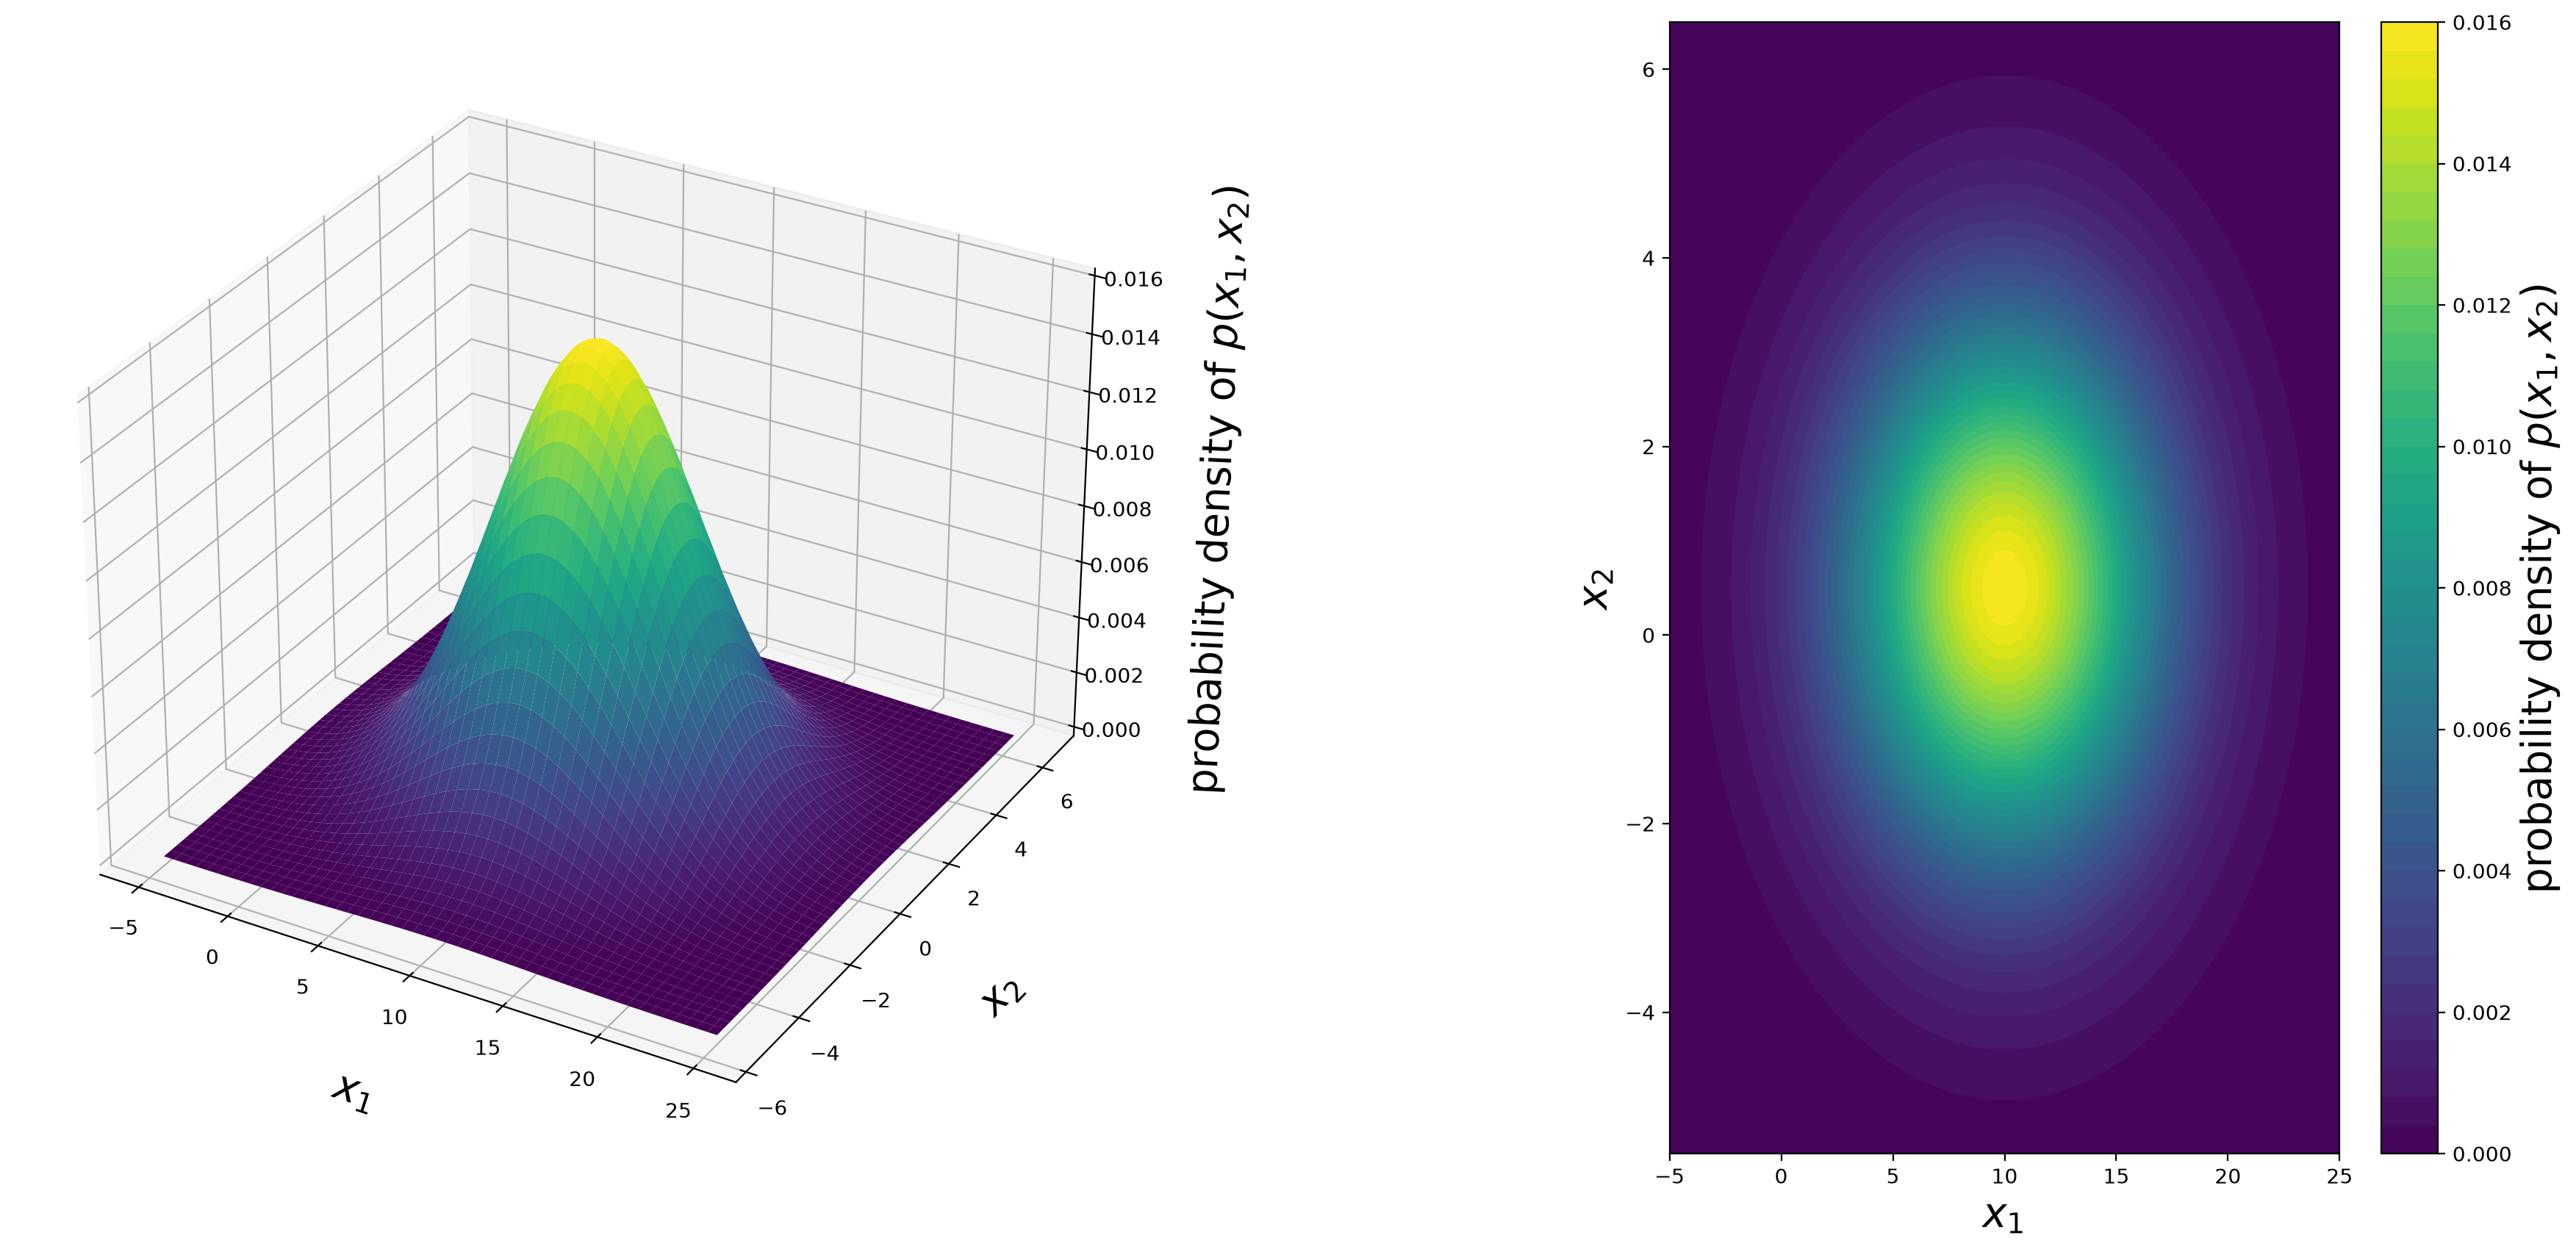

In [5]:
# Same pdf but now as a surface plot and as a contour plot.
fig_joint_pdf_HW2_ex5_color

## Car stopping distance problem (I know how much you missed it!)

Back to our simple car stopping distance problem with constant velocity $x=75$ m/s.

We have two rv's for this problem,

$$
\mathbf{x}=\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}= \begin{bmatrix}
y \\
z
\end{bmatrix}
$$

* Note: this $\mathbf{x}$ has NOTHING to do with our velocity variable $x$. Be careful!

$$
\begin{align}
\boldsymbol{\Sigma} = \text{Cov}[\mathbf{x}] &= \mathbb{E}\left[(\mathbf{x}-\mathbb{E}[\mathbf{x}])(\mathbf{x}-\mathbb{E}[\mathbf{x}])^T \right] \\
 &= \begin{bmatrix}
\mathbb{V}[y] & \text{Cov}[y,z] \\
\text{Cov}[z,y] & \mathbb{V}[z]
\end{bmatrix}
\end{align}
$$

where $\text{Cov}[y,z] = \mathbb{E}\left[(y-\mathbb{E}[y])(z-\mathbb{E}[z])\right] = \mathbb{E}[y z] - \mathbb{E}[y]\mathbb{E}[z]$

### Homework 2 (Exercise 6): Covariance matrix for the car problem when $x=75$ m/s

1. Calculate the mean vector and covariance matrix values for our car stopping distance problem (with $x=75$ m/s). **Be careful** that $y$ is dependent on $z$.

2. Calculate the determinant of the covariance matrix.

The next slide plots the multivariate Gaussian $p(y,z)$ obtained from the mean vector and covariance matrix you calculated.

This result for the determinant of $\text{Cov}[\mathbf{x}]\equiv\text{Cov}\left[\begin{matrix}y\\z\end{matrix}\right]$ arises from the fact that $y$ is **linearly** dependent on $z$.

Yet, be careful when interpreting covariance values and the covariance matrix!

* Independent implies uncorrelated: if two rv's $y$ and $z$ are **independent**, then $\text{Cov}[y,z]=0$

* **But** uncorrelated does not imply independent: two rv's can be **uncorrelated** ($\text{Cov}[y,z]=0$) but they may not be independent!


In [6]:
from scipy.stats import multivariate_normal # import from scipy.stats the multivariate Gaussian distribution

# Create a function that plots the MVN for the car stopping distance problem.
# Note: the joint pdf p(y,z) includes the Dirac delta, so I include Tikhonov regularization to plot p(y,z).
def plot_car_MVN_regularized(tikhonov_regularization):
    x = 75 # x is not an rv so its mean is equal to its value, i.e. E[x] = mu_x = x
    mu_z = 1.5; sigma_z = 0.5; # parameters of p(z)
    mu_y = x*mu_z+0.1*x**2; sigma_y = np.sqrt(sigma_z**2*x**2); # parameters of p(y)
    # Calculate elements of the Covariance matrix
    Variance_z = sigma_z**2
    Expected_z = mu_z
    Variance_y = sigma_z**2*x**2 # Variance of y (calculated by students in Homework 2)
    Expected_y = mu_z*x+0.1*x**2 # E[y] = mu_y (calculated by students in Homework 2), i.e. the mean of y (given z)
    Expected_yz = (sigma_z**2+mu_z**2)*x+0.1*x**2*mu_z # E[yz] 
    #
    Covariance_yz = Expected_yz - Expected_y*Expected_z # covariance between y and z
    #
    Covariance_matrix = [[Variance_y+tikhonov_regularization, Covariance_yz],
                         [Covariance_yz                     , Variance_z+tikhonov_regularization]]
    #
    mean_vector = [Expected_y, Expected_z]
    #
    MVN_rvs = multivariate_normal(mean_vector, Covariance_matrix) # this is p(y,z)
    #
    N_samples = 1000 # number of samples
    #
    # Create grid of points for plotting the MVN pdf
    y_grid, z_grid = np.mgrid[-3*sigma_y+mu_y:3*sigma_y+mu_y:6*sigma_y/N_samples, # Define range of y_grid
                              -3*sigma_z+mu_z:3*sigma_z+mu_z:6*sigma_z/N_samples] # Define z_grid
    #
    pos = np.dstack((y_grid, z_grid)) # put all the grid points into a single matrix for convenience
    MVN_pdf_grid = MVN_rvs.pdf(pos) # calculate p(y,z) for each grid point
    #
    #Make a 3D plot
    fig_MVN = plt.figure()
    gs = GridSpec(1, 3) # to handle subplot placement easier
    # Subplot with a 3D surface of the joint pdf p(y,z):
    ax_MVN_surface = fig_MVN.add_subplot(gs[0,:2], projection='3d') # use 1x2 grid to make 3D plot bigger
    ax_MVN_surface.set_facecolor('white') # set background for this subplot
    ax_MVN_surface.plot_surface(z_grid, y_grid, MVN_pdf_grid,cmap='viridis',linewidth=0)
    ax_MVN_surface.set_xlabel('z', fontsize=20)
    ax_MVN_surface.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_MVN_surface.set_ylabel('y', fontsize=20)
    ax_MVN_surface.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_MVN_surface.set_zlabel('probability density of p(y, z)', fontsize=20)
    ax_MVN_surface.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_MVN_surface.set_title('Multivariate Normal distribution (MVN)', fontsize=20)
    # Subplot with the contour of the joint pdf p(y,z)
    ax_MVN_contour = fig_MVN.add_subplot(gs[0,2])
    CS = ax_MVN_contour.contourf(z_grid, y_grid, MVN_pdf_grid, 50, cmap="viridis")
    ax_MVN_contour.set_xlabel('z', fontsize=20)
    ax_MVN_contour.set_ylabel('y', fontsize=20)
    cbar = fig_MVN.colorbar(CS) # Make a colorbar for the ContourSet returned by the contourf call.
    cbar.ax.set_ylabel('probability density of p(y, z)', fontsize=20)
    ax_MVN_contour.set_title('Multivariate Normal distribution (MVN)', fontsize=20)
    #
    # Create figure with specified size
    fig_MVN.set_size_inches(25, 10)

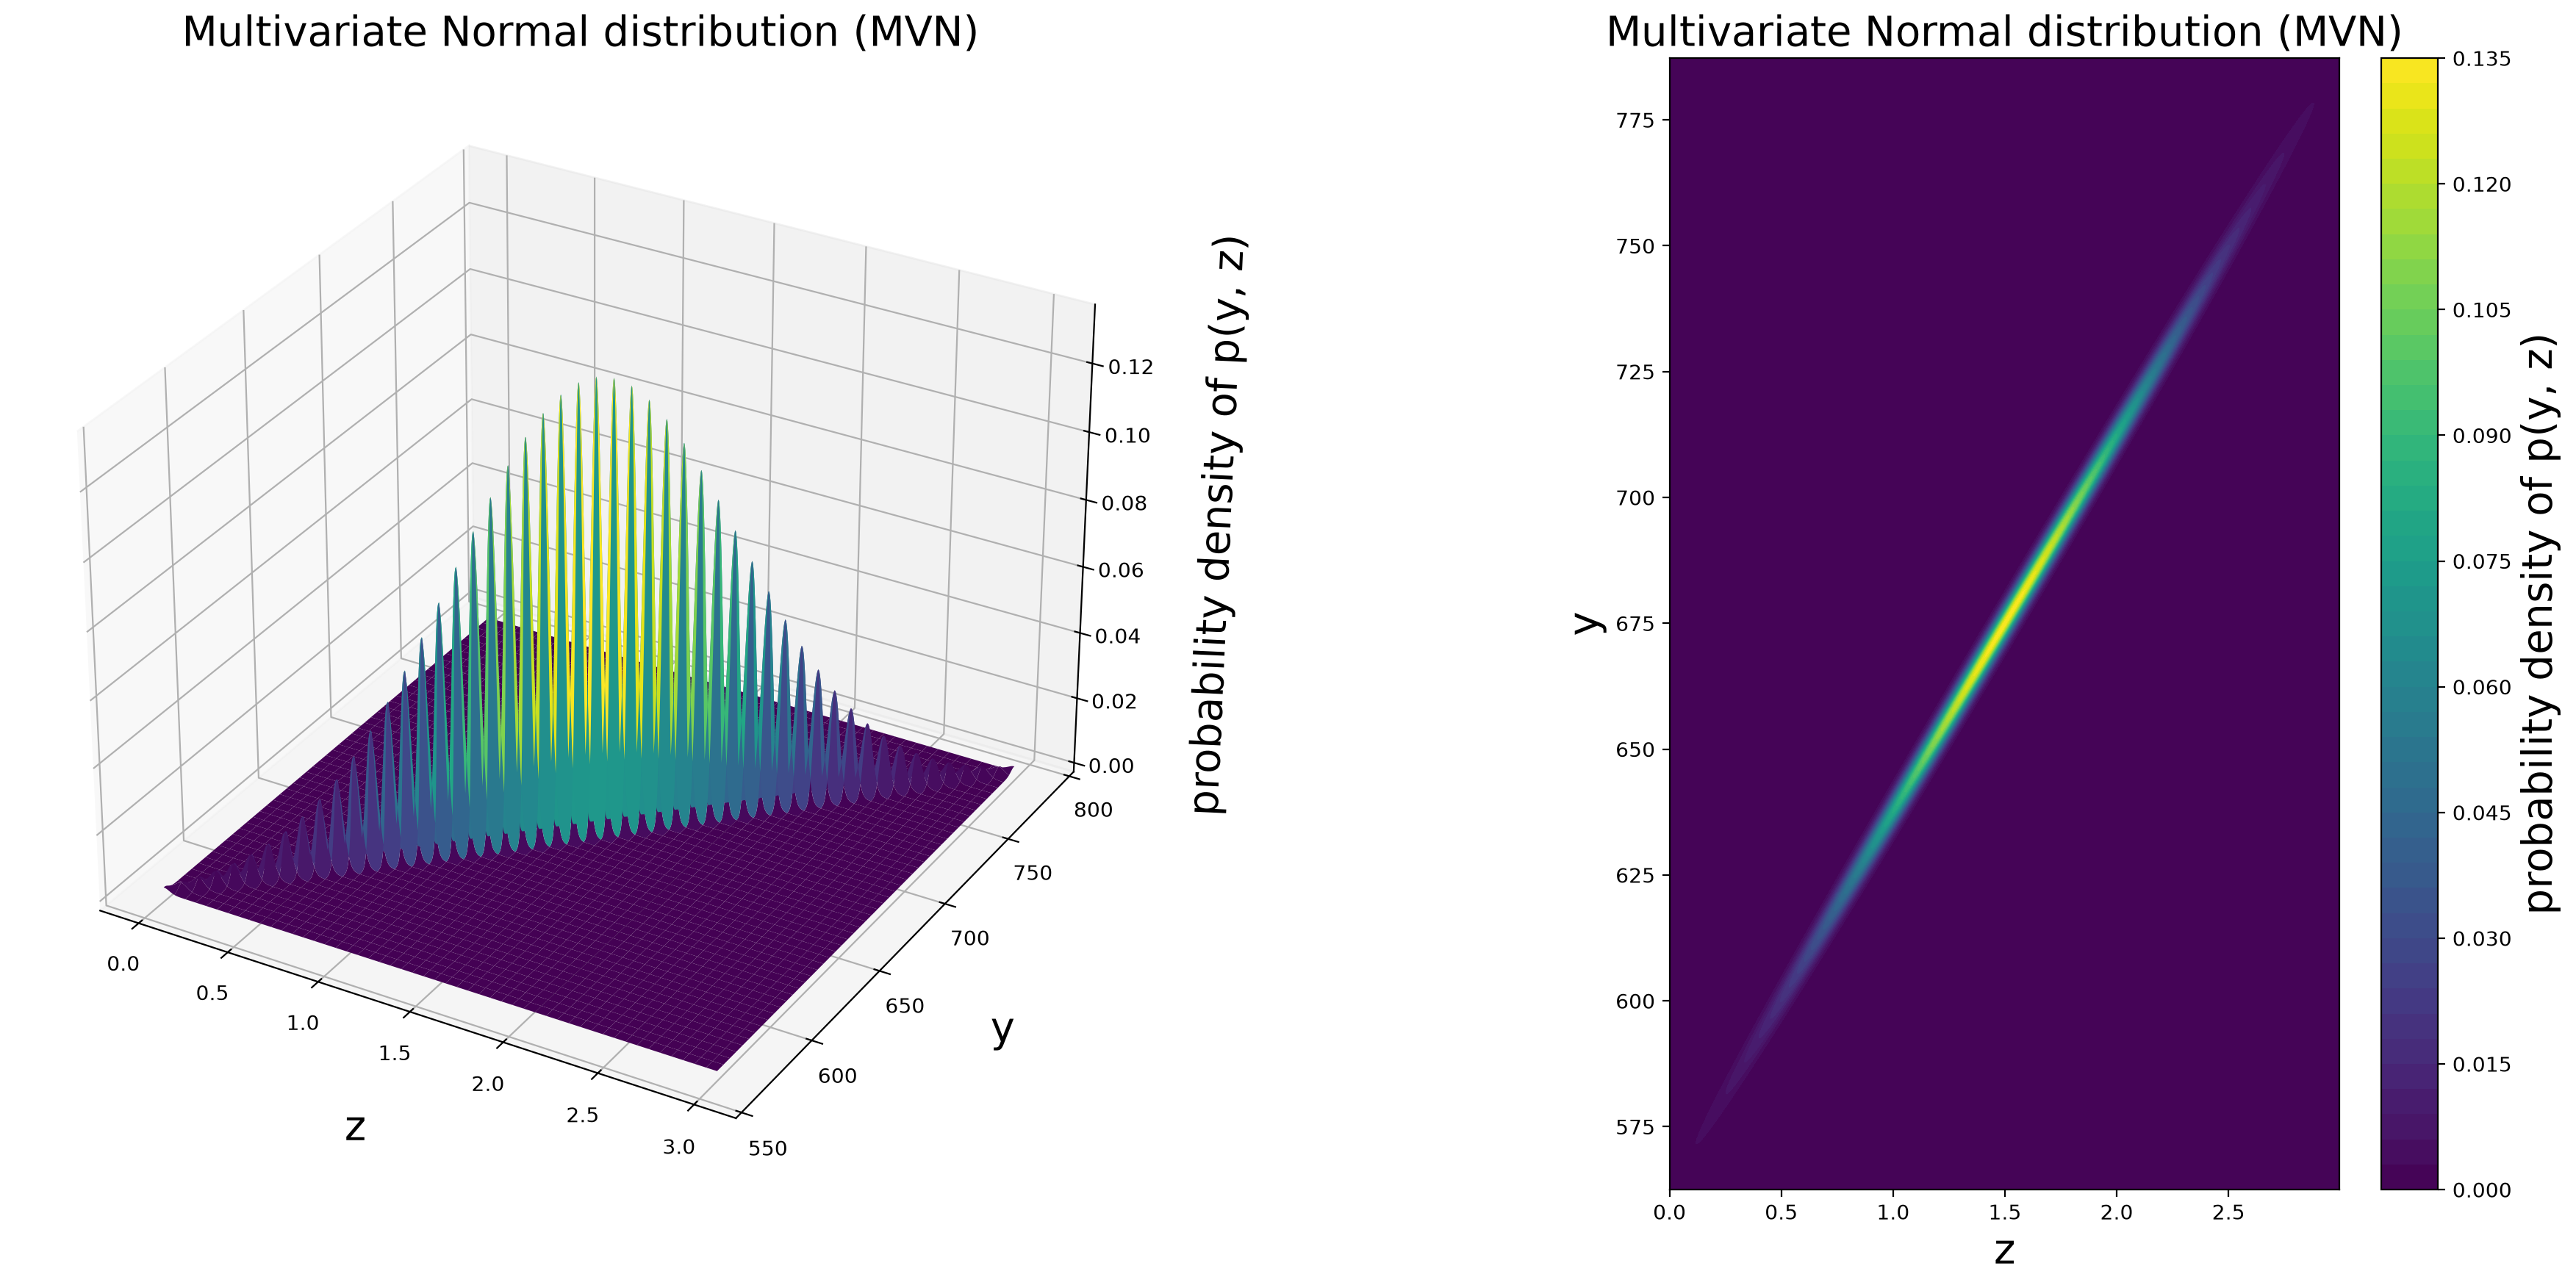

In [7]:
# Code to generate this figure is hidden in presentation (shown in notes)
regularizer = 1e-3 # Thikhonov regularization to approximate p(y,z) for car stopping distance problem
plot_car_MVN_regularized(regularizer) # SHOW WHAT HAPPENS IF regularizer is 0.1, 1e-3 and 1e-4

### Recal the joint pdf $p(y,z)$ we found for this problem in Lecture 3!

We determined in Lecture 3 that the joint pdf $p(y,z)$ for this problem is

$$
p(y, z) = \delta\left(y-(75 z+562.5)\right) p(z)
$$

where $p(z) = \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)$, and $p(y|z)=\delta\left(y-(75 z+562.5)\right)$ is the Dirac delta pdf that assigns zero probability everywhere except when $y=75 z+562.5$.
* Recall that $y=75 z+562.5$ was obtained from $y=z x+0.1x^2$ when fixing $x=75$ m/s.

* Now we see how to approximate this pdf for plotting it:
    * We can consider that the joint pdf $p(y,z)$ is an MVN, and include a small term in the diagonal of the Covariance matrix to plot it! As this term tends to zero, we retrieve the Dirac delta effect.

### What if the conditional pdf was different?

Let's consider a slightly different case where, instead of knowing that $p(y|z) = \delta\left(y-(75 z+562.5)\right)$, we consider the conditional pdf as:

$$p(y|z) = \mathcal{N}\left(y|\mu_{y|z}=75 z+562.5,\sigma_{y|z}^2=30^2\right)$$

and that we still consider $p(z) = \mathcal{N}\left(z|\mu_z=1.5,\sigma_z^2=0.5^2\right)$.

We will see in the next lectures what this choice means in the context of the car stopping distance problem...

Given the above considerations, the joint pdf is now:

$$p(y,z) = \mathcal{N}\left(y|\mu_{y|z}=75 z+562.5,\sigma_{y|z}^2=30^2\right) \mathcal{N}\left(z|\mu_z=1.5,\sigma_z^2=0.5^2\right)$$

In [8]:
# Let's plot the conditional, prior and joint pdfs:
x = 75; # constant velocity

# Parameters for p(z):
mu_z = 1.5; sigma_z = 0.5;

# Parameters for p(y|z):
def calculate_mu_yGIVENz(z_value,x): # note that the mean of p(y|z) depends on z
    mu_yGIVENz = x*z_value+0.1*x**2
    return mu_yGIVENz

# Below I will also include a "function" to compute the std of p(y|z) dependent on z
# but this is not needed because in this example the std is always the same for any z.
def calculate_sigma_yGIVENz(): # note that the std of p(y|z) does NOT depend on z
    sigma_yGIVENz = 30 # Assumed value for the standard deviation of y|z (this one actually does not depend on z)
    return sigma_yGIVENz

#------------------------------------------------------------------------------------------
# It's instructive to calculate p(z), p(y|z) and p(y,z) by defining functions (although it is slower...)

# Calculate a sample from p(z), i.e. z ~ N(mu_z, sigma_z):
def pdf_z(z_value,mu_z, sigma_z):
    pdf_z = norm.pdf(z_value, mu_z, sigma_z) # p(z_value)
    return pdf_z

# Parameters for p(y|z):
def pdf_yGIVENz(y_value,z_value, x):
    # NOTE two things about p(y|z):
    #      1. this pdf is both a function of y and of the given values of z
    #      2. this pdf has a constant variance, but that is not the case for its mean!
    mu_yGIVENz = calculate_mu_yGIVENz(z_value,x) # note that mean of p(y|z) depends on the value of z
    sigma_yGIVENz = calculate_sigma_yGIVENz() # in this case it's always a constant
    pdf_yGIVENz = norm.pdf(y_value, mu_yGIVENz, sigma_yGIVENz) # p(y_value|z_value)
    return pdf_yGIVENz

# Parameters for joint pdf p(y,z):
def pdf_joint_y_z(y_value,z_value, x,mu_z,sigma_z):
    # compute p(y_value,z_value) by calling the respective functions:
    pdf_joint_y_z = pdf_yGIVENz(y_value,z_value, x)*pdf_z(z_value,mu_z, sigma_z)
    # just one sample from p(y,z)
    return pdf_joint_y_z

# Take a sample from z ~ p(z) and y ~ p(y|z):
def samples_from_y_and_z(mu_z,sigma_z,x):
    sample_z = norm.rvs(mu_z, sigma_z, size=1) # just one sample from p(z)
    mu_yGIVENz = calculate_mu_yGIVENz(sample_z,x) # note that mean of p(y|z) depends on the value of z
    sigma_yGIVENz = calculate_sigma_yGIVENz() # in this case it's always a constant
    sample_yGIVENz = norm.rvs(mu_yGIVENz, sigma_yGIVENz, size=1) # just one sample from p(y|z)
    return sample_yGIVENz.item(), sample_z.item()
#------------------------------------------------------------------------------------------

N_samples = 300 # number of samples to create histograms and plots
# Create grid of points for plotting the p(y,z):
z_grid_min = -3*sigma_z+mu_z # minimum value of z in plot
z_grid_max = 3*sigma_z+mu_z # maximum value of z in plot

# Determining the range of y can be a little tricky because we don't know p(y).
# We don't know yet how to calculate the marginal pdf p(y), as we need to solve the integral
# of the joint pdf p(y,z) wrt to z and we have not learned how to do that yet
# (we will learn that in the next lecture). Anyway, the result is a Gaussian with mu_y and
# sigma_y equal to:
mu_y = x*mu_z+0.1*x**2
sigma_y = np.sqrt( x**2*( (calculate_sigma_yGIVENz()/x)**2 + sigma_z**2 ) )

# So, now we can calculate the grid of points for plotting p(y,z)
y_grid_min = -3*sigma_y+mu_y # minimum value of y in plot
y_grid_max =  3*sigma_y+mu_y # maximum value of y in plot

# Define range of y_grid
y_grid, z_grid = np.mgrid[y_grid_min:y_grid_max:6*sigma_y/N_samples,
                           z_grid_min:z_grid_max:6*sigma_z/N_samples]
#
pos = np.dstack((y_grid, z_grid)) # put all the grid points into a single matrix for convenience
joint_pdf_y_z_grid = np.zeros_like(y_grid)
for idx_i, pos_i in enumerate(pos):
    for idx_j, pos_j in enumerate(pos_i):
        z_value = pos_j[1] # z1 value for this grid point
        y_value = pos_j[0] # z1 value for this grid point
        joint_pdf_y_z_grid[idx_i,idx_j] = pdf_joint_y_z(y_value,z_value, x,mu_z,sigma_z)

samples_yGIVENz = np.zeros(N_samples); samples_z = np.zeros(N_samples);
# Create N_samples of z and y:
for i_sample in range(N_samples):
    samples_yGIVENz[i_sample], samples_z[i_sample] = samples_from_y_and_z(mu_z,sigma_z,x)

# This figure is created such that the histograms seem a projection of the 3D plot
# I used a simple trick of creating a grid of 4x3 subplots and assigning a 3x3 grid to the 3D plot alone
fig_joint_pdf_new = plt.figure()
gs = GridSpec(4, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf_new = fig_joint_pdf_new.add_subplot(gs[1:,0:], projection='3d')
ax_joint_pdf_new.set_facecolor('white') # set background for this subplot
ax_joint_pdf_new.plot_wireframe(z_grid, y_grid, joint_pdf_y_z_grid, color = 'grey', alpha=0.5)
# samples in the z1-y plane:
ax_joint_pdf_new.scatter(samples_z,samples_yGIVENz,np.zeros(N_samples), alpha = .7, s = 10)
# show the mean in z1-y plane:
ax_joint_pdf_new.scatter(np.mean(samples_z), np.mean(samples_yGIVENz), marker = "d", c = "r", s=100)
ax_joint_pdf_new.set_xlabel(r"$z$", fontsize=20)
ax_joint_pdf_new.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_ylabel(r"$y$", fontsize=20)
ax_joint_pdf_new.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_zlabel(r"$p(y,z)$", fontsize=20)
ax_joint_pdf_new.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_xlim3d(z_grid_min,z_grid_max) # z1 axis limits
ax_joint_pdf_new.set_ylim3d(y_grid_min,y_grid_max) # y axis limits
#ax_joint_pdf.set_title("Joint probability: $p(y,z1)$ [for fixed x=75]", fontsize=20)

# Remind the histogram and pdf for the marginal pdf p(z):
zrange = np.linspace(z_grid_min,z_grid_max,N_samples) # z range for plotting p(z1)
ax_hist_z_new = fig_joint_pdf_new.add_subplot(gs[0,2])
ax_hist_z_new.hist(samples_z, bins='auto', density=True, label='Histogram')  
ax_hist_z_new.plot(zrange, norm.pdf(zrange, mu_z, sigma_z), 'k--', linewidth = 3, label='$p(z)$')
ax_hist_z_new.set_xlabel("$z$", fontsize=20)
ax_hist_z_new.set_ylabel("probability density", fontsize=20)
ax_hist_z_new.legend(fontsize=15, loc='upper left');

# Finally, let's plot the pdf of p(y) that is obtained by integrating the joint pdf p(y,z) wrt to z:
yrange = np.linspace(-3*sigma_y+mu_y,3*sigma_y+mu_y,N_samples) # y range for plotting p(y)
samples_y = norm.rvs(mu_y, sigma_y, size=N_samples) # samples from p(y) for histogram
ax_hist_y_new = fig_joint_pdf_new.add_subplot(gs[0,0]) # place it in position [1,0] in the 3x3 grid
ax_hist_y_new.hist(samples_y, bins='auto', density=True, label='Histogram')  
ax_hist_y_new.plot(yrange, norm.pdf(yrange, mu_y, sigma_y),
                 'k--', linewidth = 3, label='$p(y)$')
ax_hist_y_new.set_xlabel("$y$", fontsize=20)
ax_hist_y_new.set_ylabel("probability density", fontsize=20)
ax_hist_y_new.legend(fontsize=15, loc='upper left');

# Create figure with specified size but close it so that we open the figure just for presentation
fig_joint_pdf_new.set_size_inches(20, 10) # scale figure to be wider (since there are 2 subplots)
plt.close(fig_joint_pdf_new) # do not plot the figure now. We will show it in a later cell

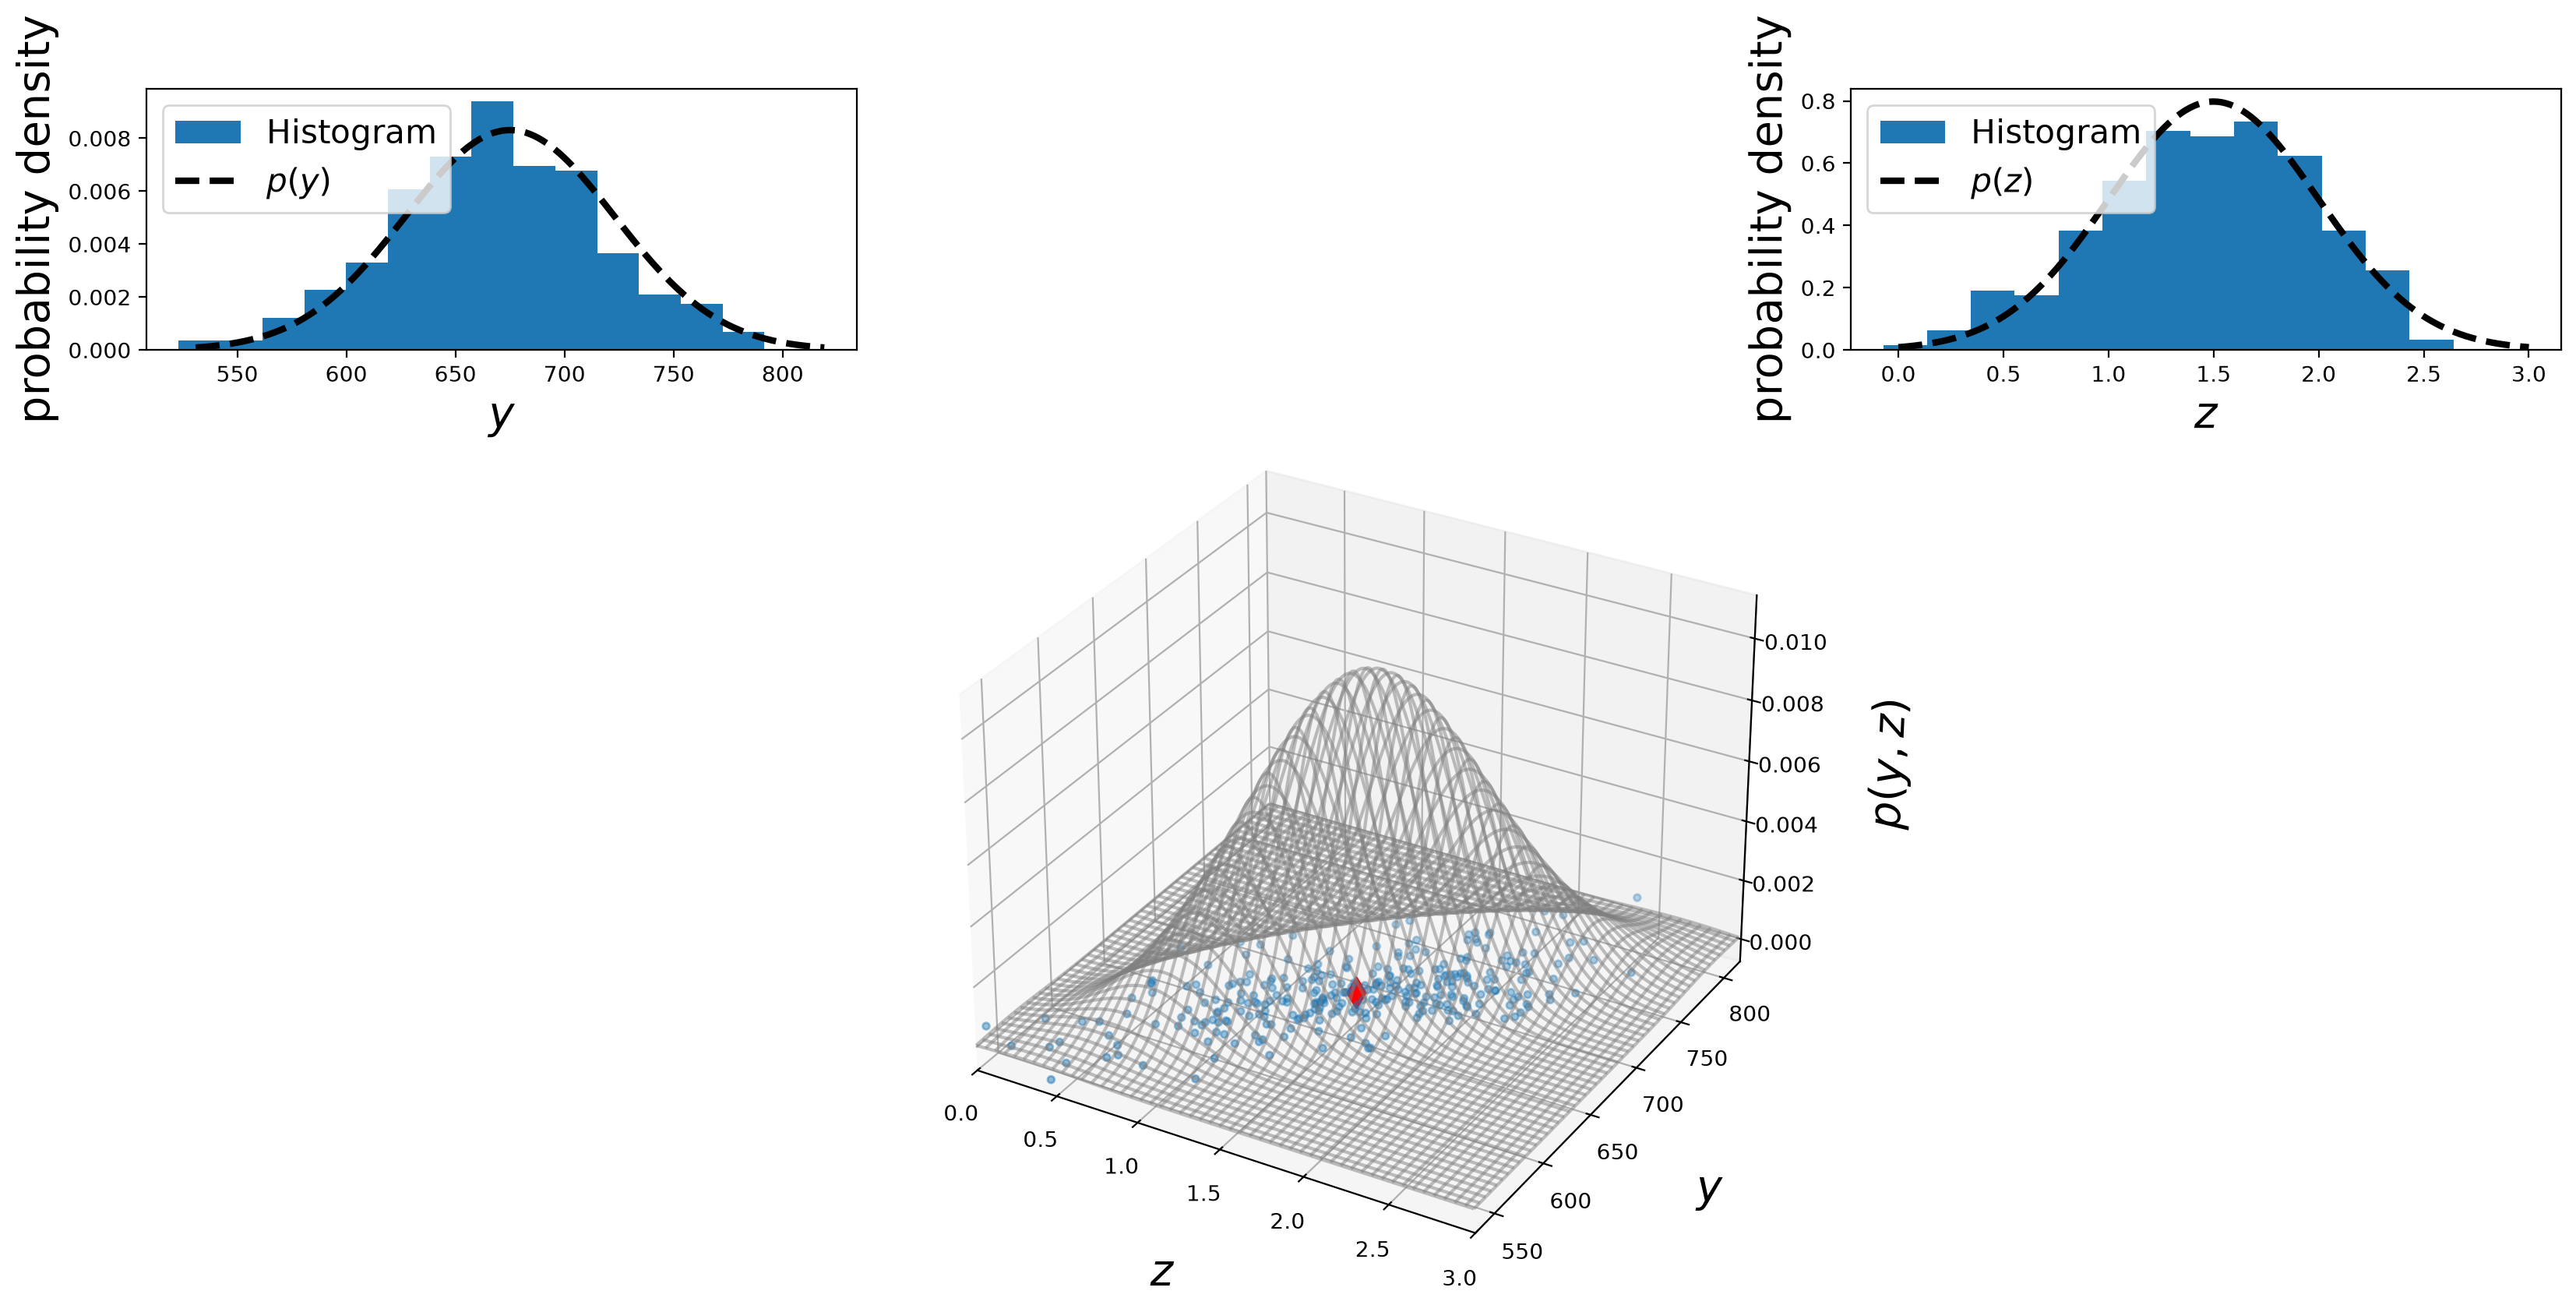

In [9]:
# HIGHLIGHT DIFFERENCE IN MAXIMUM PROBABILITY DENSITIES!!
fig_joint_pdf_new # The joint pdf results from the multiplication...

In [10]:
def fig2_joint_pdf_new(y_value,z_value): # Plot joint pdf again but now also show the two conditional pdfs
    # Replot the same joint pdf but using contour lines, so that students understand what a conditional pdf is.
    fig_joint_pdf_new_color = plt.figure()
    gs = GridSpec(1, 3) # to handle subplot placement easier

    # Subplot with a 3D surface of the joint pdf p(y,z):
    ax_joint_pdf_new_color_surface = fig_joint_pdf_new_color.add_subplot(gs[0,:2], projection='3d') # use 1x2 grid
    ax_joint_pdf_new_color_surface.set_facecolor('white') # set background for this subplot
    ax_joint_pdf_new_color_surface.contour3D(z_grid, y_grid, joint_pdf_y_z_grid, levels = 50,
                                            alpha = .2, cmap = "viridis")
    
    # Plot the pdf of p(y|z=z_value)
    yrange = np.linspace(y_grid_min,y_grid_max,N_samples) # y range for plotting p(y|z1)
    pdf_yGIVENz = np.zeros_like(yrange)
    for i_point in range(N_samples):
        pdf_yGIVENz[i_point] = pdf_joint_y_z(yrange[i_point],z_value, x,mu_z,sigma_z)
    ax_joint_pdf_new_color_surface.plot3D(z_value*np.ones_like(yrange), yrange, pdf_yGIVENz, 'r')
    
    # Plot the pdf of p(z|y=y_value)
    z1range = np.linspace(z_grid_min,z_grid_max,N_samples) # y range for plotting p(y|z1)
    pdf_zGIVENy = np.zeros_like(zrange)
    for i_point in range(N_samples):
        pdf_zGIVENy[i_point] = pdf_joint_y_z(y_value,zrange[i_point], x,mu_z,sigma_z)
    ax_joint_pdf_new_color_surface.plot3D(zrange, y_value*np.ones_like(zrange), pdf_zGIVENy, 'g')
    #
    ax_joint_pdf_new_color_surface.scatter(mu_z, mu_y, marker = "x", c = "k", s=100)
    ax_joint_pdf_new_color_surface.set_xlabel('$z$', fontsize=20)
    ax_joint_pdf_new_color_surface.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_joint_pdf_new_color_surface.set_ylabel('$y$', fontsize=20)
    ax_joint_pdf_new_color_surface.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_joint_pdf_new_color_surface.set_zlabel('probability density of $p(y, z)$', fontsize=20)
    ax_joint_pdf_new_color_surface.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    title_string = "Red line $p(y|z=%1.1f)$  and Green line is $p(z|y=%1.1f)$" % (z_value, y_value)
    ax_joint_pdf_new_color_surface.set_title(title_string,fontsize=20)

    # Subplot with the contour of the joint pdf p(y,z)
    ax_joint_pdf_new_color_contour2 = fig_joint_pdf_new_color.add_subplot(gs[0,2])
    CS = ax_joint_pdf_new_color_contour2.contourf(z_grid, y_grid, joint_pdf_y_z_grid, 50, cmap="viridis")
    ax_joint_pdf_new_color_contour2.plot(z_value*np.ones_like(yrange), yrange,'r')
    ax_joint_pdf_new_color_contour2.plot(zrange, y_value*np.ones_like(zrange),'g')
    ax_joint_pdf_new_color_contour2.scatter(mu_z, mu_y, marker = "x", c = "k", s=100)
    ax_joint_pdf_new_color_contour2.set_xlabel('$z$', fontsize=20)
    ax_joint_pdf_new_color_contour2.set_ylabel('$y$', fontsize=20)
    ax_joint_pdf_new_color_contour2.set_xlim(z_grid_min, z_grid_max)
    ax_joint_pdf_new_color_contour2.set_ylim(y_grid_min, y_grid_max)
    cbar = fig_joint_pdf_new_color.colorbar(CS) # Make a colorbar for the ContourSet returned by the contourf call.
    cbar.ax.set_ylabel('probability density of $p(y, z)$', fontsize=20)

    # Create figure with specified size
    fig_joint_pdf_new_color.set_size_inches(25, 10)
    display(fig_joint_pdf_new_color)
    plt.close(fig_joint_pdf_new_color) # keep it out of pyplot's registry so it cannot go stale


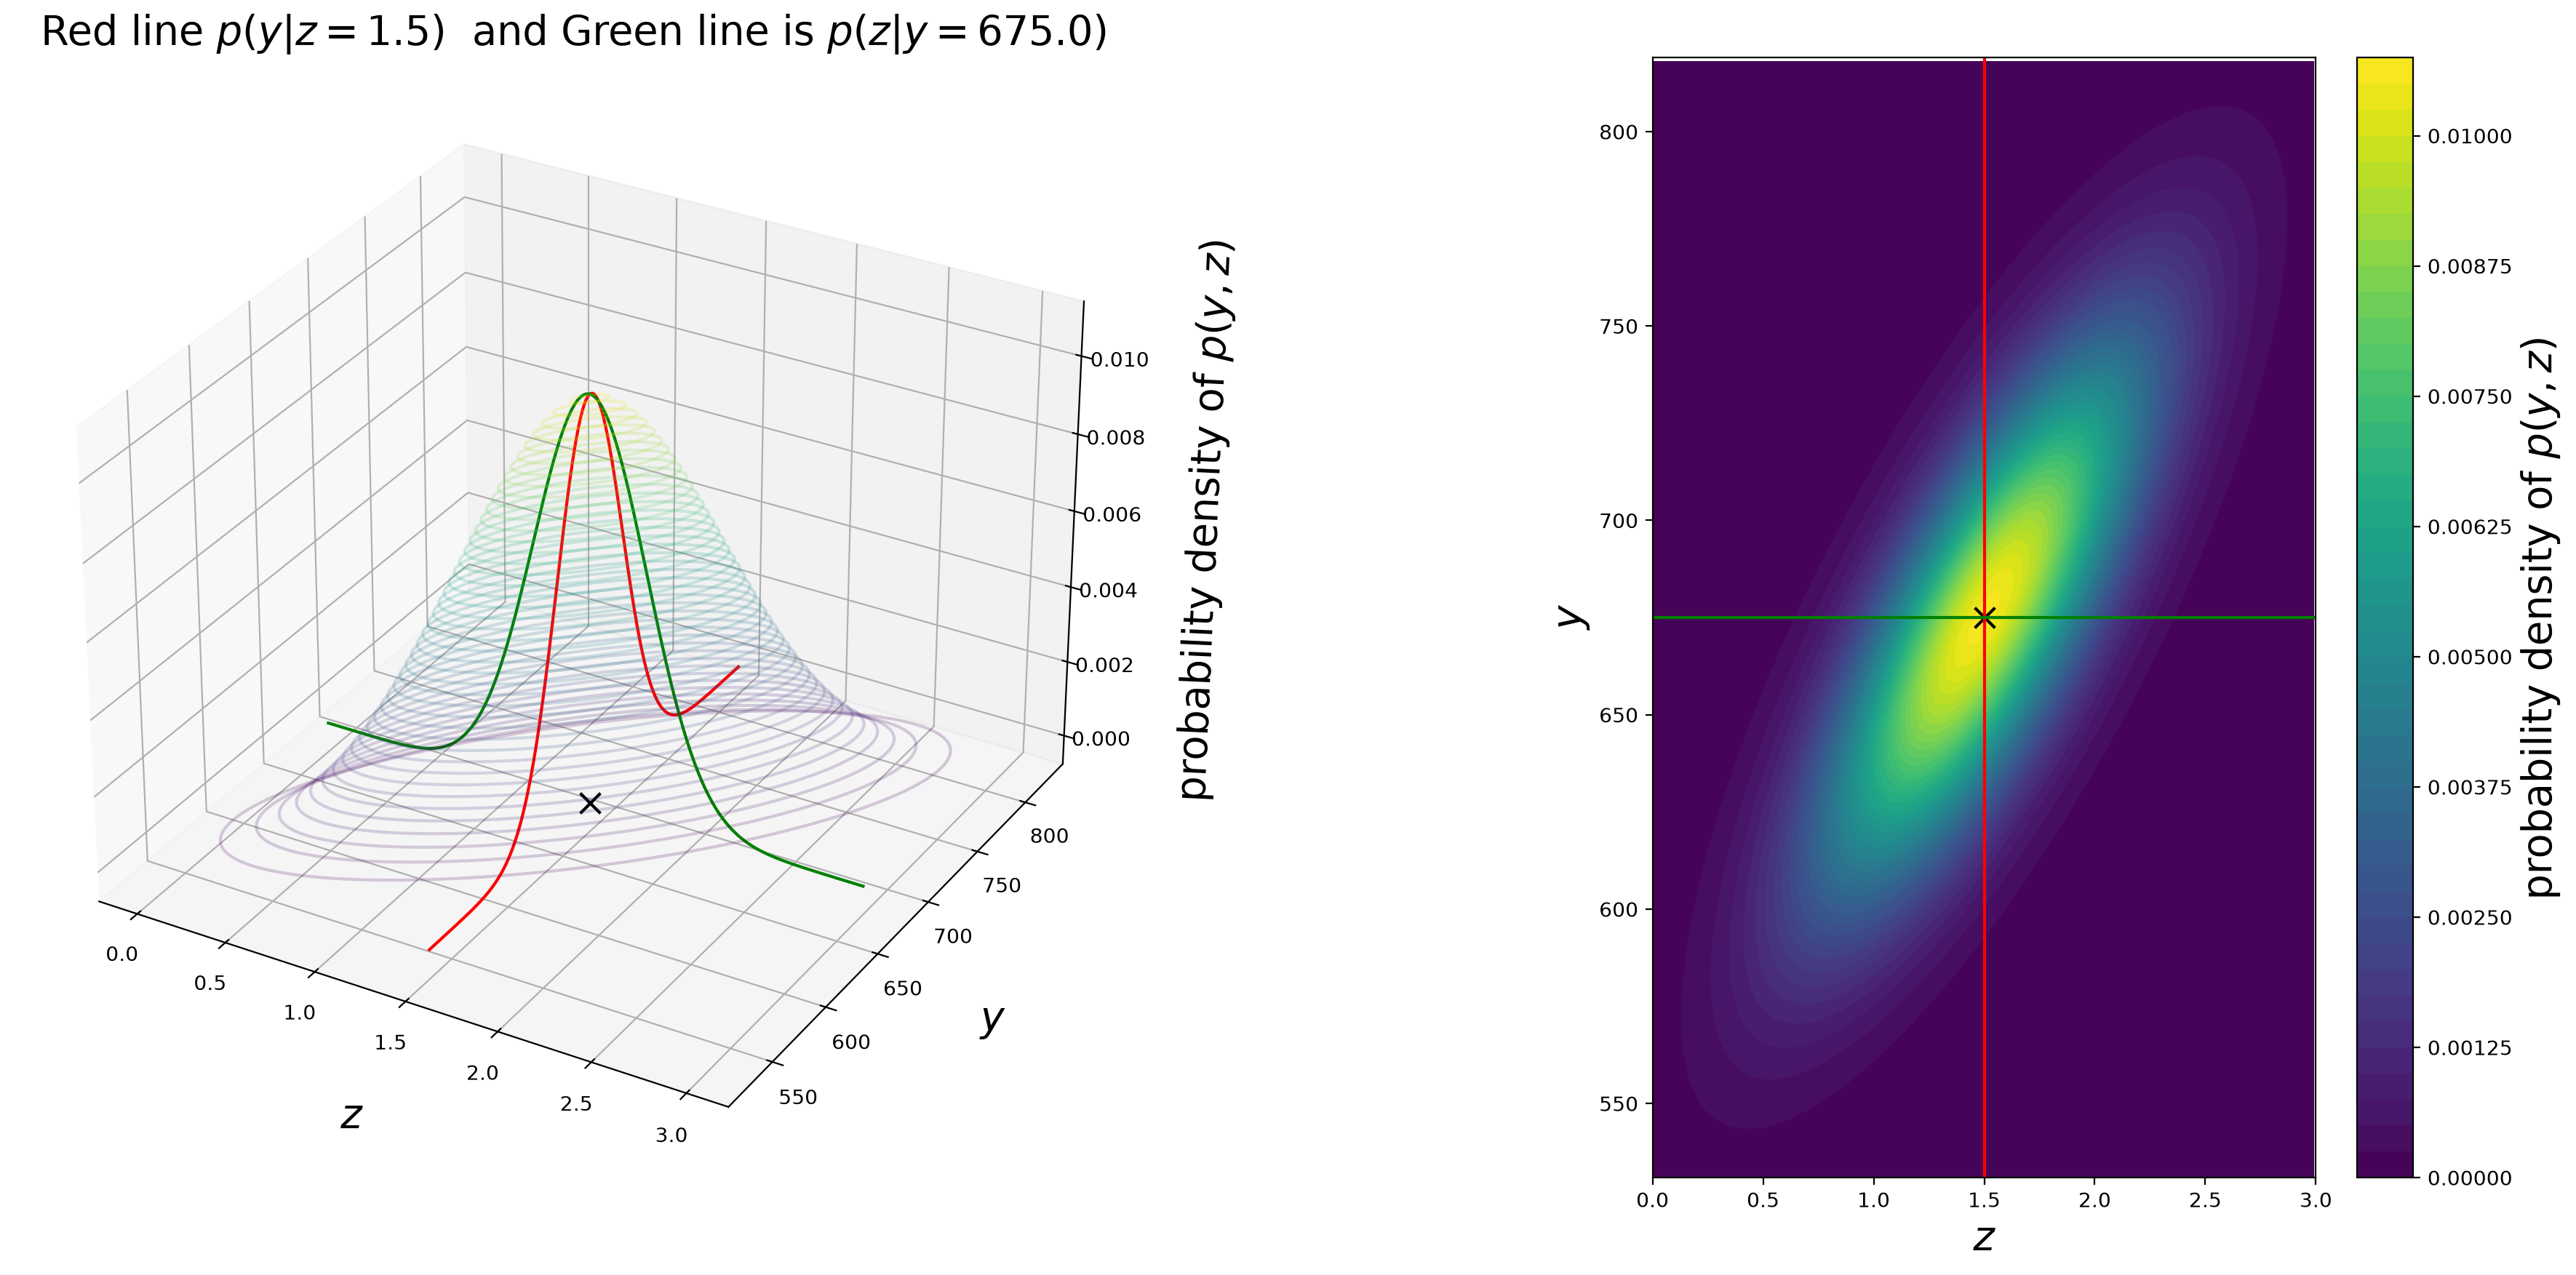

In [11]:
# Static plot (I skip this cell in presentations, but use it when printing slides to PDF)
fig2_joint_pdf_new(y_value=mu_y,z_value=mu_z)

In [12]:
# Hidden. Builds the interactive joint pdf.
#
# The JavaScript below is a RENDERER ONLY -- it contains no probability formula.
# The field it draws is joint_pdf_y_z_grid, computed by the Python above and handed
# over as integers, so the interactive plot and the static plot cannot disagree:
# they are the same numbers. Change x, mu_z, sigma_z or the model and both follow.
import numpy as np
from IPython.display import HTML

_G = np.asarray(joint_pdf_y_z_grid)[::2, ::2].T          # [y,z] -> [z,y]
_PMAX = float(_G.max())
_grid_js = "[" + ",".join("[" + ",".join(str(int(v)) for v in row) + "]"
                          for row in np.round(_G / _PMAX * 65535)) + "]"

_joint_pdf_html = (r'''<div style="font-family:system-ui,sans-serif;max-width:1000px">
<canvas id="j3-c" width="1900" height="840" style="width:950px;height:420px;border:1px solid #ccc;cursor:grab"></canvas>
<div style="display:flex;gap:26px;flex-wrap:wrap;margin-top:8px;font-size:14px;align-items:center">
  <label style="display:inline-flex;align-items:center;gap:6px"><span style="color:#d62728">red</span> &nbsp;p(y | z), slice at z = <input id="j3-z" type="range" step="0.005"><span id="j3-z-v"></span></label>
  <label style="display:inline-flex;align-items:center;gap:6px"><span style="color:#2ca02c">green</span> &nbsp;p(z | y), slice at y = <input id="j3-y" type="range" step="0.5"><span id="j3-y-v"></span></label>
</div>
<div style="font-size:13px;color:#555;margin-top:6px">Drag the surface to rotate it.</div>
</div>
<script>
(function(){
 // A RENDERER ONLY. The field comes from the notebook: GRID is joint_pdf_y_z_grid
 // as computed by the Python above, transposed to [z][y] and quantised to 16 bits.
 // There is no probability formula in this file.
 var GRID=__GRID__, PMAX=__PMAX__;
 var Z0=__Z0__, Z1=__Z1__, Y0=__Y0__, Y1=__Y1__, MUZ=__MUZ__, MUY=__MUY__;
 var NG=GRID.length-1;
 function gv(i,j){return GRID[i][j]/65535*PMAX;}
 function sample(u,v){
   var a=Math.max(0,Math.min(NG-1e-9,u*NG)), b=Math.max(0,Math.min(NG-1e-9,v*NG));
   var i=Math.floor(a), j=Math.floor(b), fa=a-i, fb=b-j;
   return gv(i,j)*(1-fa)*(1-fb)+gv(i+1,j)*fa*(1-fb)+gv(i,j+1)*(1-fa)*fb+gv(i+1,j+1)*fa*fb;
 }
 var VIR=[[68,1,84],[72,40,120],[62,74,137],[49,104,142],[38,130,142],[31,158,137],
          [53,183,121],[109,205,89],[180,222,44],[253,231,37]];
 function vir(t){t=Math.max(0,Math.min(1,t))*(VIR.length-1);var i=Math.floor(t),f=t-i,
   a=VIR[i],b=VIR[Math.min(i+1,VIR.length-1)];
   return 'rgb('+Math.round(a[0]+(b[0]-a[0])*f)+','+Math.round(a[1]+(b[1]-a[1])*f)+','+
          Math.round(a[2]+(b[2]-a[2])*f)+')';}
 var c=document.getElementById('j3-c'),g=c.getContext('2d'),S=2;
 var N=NG, grid=GRID.map(function(r){return r.map(function(v){return v/65535*PMAX;});});
 var az=0.45, el=0.45, drag=null;   // default view
 var CX=c.width*0.255, CY=c.height*0.63, SC=c.height*0.375;
 function proj(u,v,w){            // u,v,w all in [0,1]
   u=(u-0.5)*1.7; v=(0.5-v)*1.7; w=w*1.15;   // v flipped: y increases upward, as in the contour panel
   var ca=Math.cos(az),sa=Math.sin(az),ce=Math.cos(el),se=Math.sin(el);
   var U=u*ca-v*sa, V=u*sa+v*ca;
   return [CX+U*SC, CY-(w*ce-V*se)*SC, V];      // third entry = depth
 }
 // ---- right-hand 2-D contour panel
 var L2=c.width*0.585, T2=30*S, W2=c.width*0.26, H2=c.height-T2-60*S;
 var CB=L2+W2+26*S, CBW=20*S;
 var im=g.createImageData(Math.round(W2),Math.round(H2)),d=im.data;
 for(var b=0;b<im.height;b++)for(var a2=0;a2<im.width;a2++){
   var z=Z0+(Z1-Z0)*a2/(im.width-1), y=Y1-(Y1-Y0)*b/(im.height-1);
   var t=sample((z-Z0)/(Z1-Z0),(y-Y0)/(Y1-Y0))/PMAX, col=vir(t).match(/\d+/g), k=(b*im.width+a2)*4;
   d[k]=+col[0];d[k+1]=+col[1];d[k+2]=+col[2];d[k+3]=255;}
 function z2x(z){return L2+(z-Z0)/(Z1-Z0)*W2;}
 function y2y(y){return T2+(Y1-y)/(Y1-Y0)*H2;}
 function txt(s,x,y,col,al,sz){g.save();g.fillStyle=col||'#333';g.textAlign=al||'center';
   g.font=((sz||13)*S)+'px system-ui';g.fillText(s,x,y);g.restore();}
 function draw(){
  var zv=+document.getElementById('j3-z').value, yv=+document.getElementById('j3-y').value;
  document.getElementById('j3-z-v').textContent=zv.toFixed(2);
  document.getElementById('j3-y-v').textContent=yv.toFixed(1);
  g.clearRect(0,0,c.width,c.height);

 function fmt(v){return Math.abs(v)>=100?v.toFixed(0):(Math.abs(v)>=1?v.toFixed(1):v.toExponential(1));}
 function drawAxes(){
   var fl=[[0,0],[1,0],[1,1],[0,1]].map(function(p){return {u:p[0],v:p[1],s:proj(p[0],p[1],0)};});
   g.save(); g.strokeStyle='#b8b8b8'; g.lineWidth=1.2*S;
   g.beginPath(); fl.forEach(function(p,i){i?g.lineTo(p.s[0],p.s[1]):g.moveTo(p.s[0],p.s[1]);});
   g.closePath(); g.stroke();
   // vertical axis at the left-most floor corner
   var li=0; for(var i=1;i<4;i++) if(fl[i].s[0]>fl[li].s[0]) li=i;   // right-hand vertical axis
   var topP=proj(fl[li].u,fl[li].v,1);
   g.beginPath(); g.moveTo(fl[li].s[0],fl[li].s[1]); g.lineTo(topP[0],topP[1]); g.stroke();
   g.restore();
   // ticks on the two floor edges meeting at the front-most corner
   var fi=0; for(var i=1;i<4;i++) if(fl[i].s[1]>fl[fi].s[1]) fi=i;
   [(fi+1)%4,(fi+3)%4].forEach(function(ni){
     var A=fl[fi], B=fl[ni], isZ=(A.u!==B.u);
     for(var k=1;k<=3;k++){          // k=0 is the shared corner: skip it
       var t=k/3, u=A.u+(B.u-A.u)*t, v=A.v+(B.v-A.v)*t, p=proj(u,v,0);
       var val=isZ ? Z0+(Z1-Z0)*u : Y0+(Y1-Y0)*v;
       var ox=(p[0]-CX)*0.055, oy=18*S;
       txt(fmt(val), p[0]+ox, p[1]+oy, '#555','center',12);
     }
     var mp=proj((A.u+B.u)/2,(A.v+B.v)/2,0);
     txt(isZ?'z':'y', mp[0]+(mp[0]-CX)*0.16, mp[1]+44*S, '#222','center',16);
   });
   // ticks up the vertical axis
   for(var k=1;k<=3;k++){
     var p=proj(fl[li].u,fl[li].v,k/3);
     txt(fmt(PMAX*k/3), p[0]+14*S, p[1]+4*S, '#555','left',11);
   }
   var lp=proj(fl[li].u,fl[li].v,1);
   g.save(); g.translate(lp[0]+72*S, lp[1]+95*S); g.rotate(-Math.PI/2);
   txt('probability density of p(y, z)',0,0,'#222','center',12); g.restore();
 }
 drawAxes();
  // ---- surface as contour rings at constant pdf level (marching squares)
  var NL=50;
  for(var li=1;li<=NL;li++){
    var L=PMAX*li/(NL+1), segs=[];
    for(var i=0;i<N;i++)for(var j=0;j<N;j++){
      var A=grid[i][j],B=grid[i+1][j],C=grid[i+1][j+1],D=grid[i][j+1], pts=[];
      if((A>L)!==(B>L)) pts.push([i+(L-A)/(B-A), j]);
      if((B>L)!==(C>L)) pts.push([i+1, j+(L-B)/(C-B)]);
      if((D>L)!==(C>L)) pts.push([i+(L-D)/(C-D), j+1]);
      if((A>L)!==(D>L)) pts.push([i, j+(L-A)/(D-A)]);
      if(pts.length===2) segs.push(pts);
      else if(pts.length===4){segs.push([pts[0],pts[1]]);segs.push([pts[2],pts[3]]);}
    }
    if(!segs.length) continue;
    g.save();
    g.strokeStyle=vir(L/PMAX); g.lineWidth=1.1*S; g.globalAlpha=0.20;
    g.beginPath();
    segs.forEach(function(sg){
      var p0=proj(sg[0][0]/N, sg[0][1]/N, L/PMAX), p1=proj(sg[1][0]/N, sg[1][1]/N, L/PMAX);
      g.moveTo(p0[0],p0[1]); g.lineTo(p1[0],p1[1]);
    });
    g.stroke(); g.restore();
  }
  // ---- the two slice curves, riding on the surface
  function curve(fixed,which,col){
    g.save();g.strokeStyle=col;g.lineWidth=2.6*S;g.beginPath();
    for(var k=0;k<=160;k++){
      var t=k/160, u,v,p;
      if(which==='z'){u=(fixed-Z0)/(Z1-Z0); v=t;}
      else           {v=(fixed-Y0)/(Y1-Y0); u=t;}
      p=sample(u,v);
      var q=proj(u,v,p/PMAX); k?g.lineTo(q[0],q[1]):g.moveTo(q[0],q[1]);}
    g.stroke();g.restore();}
  curve(zv,'z','#d62728'); curve(yv,'y','#2ca02c');
  var mk=proj((MUZ-Z0)/(Z1-Z0),(MUY-Y0)/(Y1-Y0),0);
  g.save();g.strokeStyle='#000';g.lineWidth=2.5*S;var m=7*S;
  g.beginPath();g.moveTo(mk[0]-m,mk[1]-m);g.lineTo(mk[0]+m,mk[1]+m);
  g.moveTo(mk[0]+m,mk[1]-m);g.lineTo(mk[0]-m,mk[1]+m);g.stroke();g.restore();
  (function(){
    var parts=[['Red line p(y | z = '+zv.toFixed(2)+')','#d62728'],
               ['    and    ','#444'],
               ['Green line is p(z | y = '+yv.toFixed(1)+')','#2ca02c']];
    g.save(); g.font=(15*S)+'px system-ui'; g.textAlign='left';
    var tot=0; parts.forEach(function(p){tot+=g.measureText(p[0]).width;});
    var xx=CX-tot/2;
    parts.forEach(function(p){g.fillStyle=p[1];g.fillText(p[0],xx,26*S);xx+=g.measureText(p[0]).width;});
    g.restore();
  })();
  txt('drag to rotate',CX,c.height-16*S,'#777','center',12);
  // ---- contour panel
  g.putImageData(im,Math.round(L2),Math.round(T2));
  g.save();g.lineWidth=2.5*S;
  g.strokeStyle='#d62728';g.beginPath();g.moveTo(z2x(zv),y2y(Y0));g.lineTo(z2x(zv),y2y(Y1));g.stroke();
  g.strokeStyle='#2ca02c';g.beginPath();g.moveTo(z2x(Z0),y2y(yv));g.lineTo(z2x(Z1),y2y(yv));g.stroke();
  g.restore();
  g.save();g.strokeStyle='#000';g.lineWidth=2.5*S;
  g.beginPath();g.moveTo(z2x(MUZ)-m,y2y(MUY)-m);g.lineTo(z2x(MUZ)+m,y2y(MUY)+m);
  g.moveTo(z2x(MUZ)+m,y2y(MUY)-m);g.lineTo(z2x(MUZ)-m,y2y(MUY)+m);g.stroke();g.restore();
  txt('z',L2+W2/2,T2+H2+32*S,'#333','center',14);
  g.save();g.translate(L2-54*S,T2+H2/2);g.rotate(-Math.PI/2);txt('y',0,0,'#333','center',14);g.restore();
  for(var i=0;i<=3;i++){var z=Z0+(Z1-Z0)*i/3;txt(z.toFixed(1),z2x(z),T2+H2+16*S);}
  for(var i=0;i<=3;i++){var y=Y0+(Y1-Y0)*i/3;txt(y.toFixed(0),L2-8*S,y2y(y)+5*S,'#333','right');}
  // ---- colorbar
  for(var b=0;b<H2;b++){
    g.fillStyle=vir(1-b/H2);
    g.fillRect(CB, T2+b, CBW, 1.5);
  }
  g.save();g.strokeStyle='#888';g.lineWidth=1*S;g.strokeRect(CB,T2,CBW,H2);g.restore();
  for(var k=0;k<=4;k++){
    var yy2=T2+H2*(1-k/4);
    txt(fmt(PMAX*k/4), CB+CBW+8*S, yy2+5*S, '#555','left',11);
  }
  g.save();g.translate(CB+CBW+92*S, T2+H2/2);g.rotate(-Math.PI/2);
  txt('probability density of p(y, z)',0,0,'#222','center',12);g.restore();
 }
 c.addEventListener('mousedown',function(e){drag={x:e.clientX,y:e.clientY,az:az,el:el};c.style.cursor='grabbing';});
 window.addEventListener('mousemove',function(e){if(!drag)return;
   az=drag.az+(e.clientX-drag.x)*0.01;
   el=Math.max(0.05,Math.min(1.45,drag.el+(e.clientY-drag.y)*0.006));draw();});
 window.addEventListener('mouseup',function(){drag=null;c.style.cursor='grab';});
 var ez=document.getElementById('j3-z'),ey=document.getElementById('j3-y');
 ez.min=Z0;ez.max=Z1;ez.value=MUZ; ey.min=Y0;ey.max=Y1;ey.value=MUY;
 ez.addEventListener('input',draw); ey.addEventListener('input',draw);
 draw();
})();
</script>
'''
    .replace("__GRID__", _grid_js)
    .replace("__PMAX__", repr(_PMAX))
    .replace("__Z0__", repr(float(z_grid_min))).replace("__Z1__", repr(float(z_grid_max)))
    .replace("__Y0__", repr(float(y_grid_min))).replace("__Y1__", repr(float(y_grid_max)))
    .replace("__MUZ__", repr(float(mu_z))).replace("__MUY__", repr(float(mu_y))))
print(f"grid handed to the renderer: {_G.shape[0]}x{_G.shape[1]}, {len(_grid_js)/1024:.0f} KB")


grid handed to the renderer: 150x150, 87 KB


In [13]:
HTML(_joint_pdf_html)

## Conclusions about Gaussian distributions

Our empirical investigations in this Lecture, have led to some interesting observations! They can be generalized to:
* If two sets of variables are jointly Gaussian, i.e. if their joint pdf is an MVN, then:
    * their conditional pdfs are Gaussian, i.e. the conditional distribution of one set conditioned on the other is again Gaussian!
    * the marginal distribution of either set is also Gaussian!

<font color='blue'>This is really important because it means that Gaussians are closed under Bayesian conditioning!</font> We will explore this later.

* Note: Bishop's book has a fantastic discussion about the univariate and multivariate Gaussian distribution (Section 2.3). **I recommend reading it.** I also included it in the notes below this cell.

## Summary of partitioned Gaussians

Given a joint Gaussian pdf $p(\mathbf{x})=\mathcal{N}(\mathbf{x}|\boldsymbol{\mu},\boldsymbol{\Sigma})$ with $\boldsymbol{\Lambda}\equiv\boldsymbol{\Sigma}^{-1}$ and

$$
\mathbf{x}=\begin{bmatrix}
\mathbf{x}_a \\
\mathbf{x}_b
\end{bmatrix}, \quad \boldsymbol{\mu} = \begin{bmatrix}
\boldsymbol{\mu}_a \\
\boldsymbol{\mu}_b
\end{bmatrix}, \quad
\boldsymbol{\Sigma} = \begin{bmatrix}
\boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\
\boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb}
\end{bmatrix}, \quad \boldsymbol{\Lambda} = \begin{bmatrix}
\boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\
\boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb}
\end{bmatrix}
$$

We have the conditional distribution $p(\mathbf{x}_a,\mathbf{x}_b) = \mathcal{N}(\mathbf{x}_a|\boldsymbol{\mu}_{a|b}, \boldsymbol{\Lambda}_{aa}^{-1})$ with the following parameters:

$$
{\color{blue}{\boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a-\boldsymbol{\Lambda}_{aa}^{-1}\boldsymbol{\Lambda}_{ab}(\mathbf{x}_b-\boldsymbol{\mu}_b)}}
$$

$${\color{red}{\boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Lambda}_{aa}^{-1}}}
$$

where $\boldsymbol{\Lambda}_{aa} = \left(\boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba}\right)^{-1}$, and $\boldsymbol{\Lambda}_{aa}^{-1}\boldsymbol{\Lambda}_{ab}=\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}$.

The marginal distribution is $p(\mathbf{x}_a) = \mathcal{N}(\mathbf{x}_a|\boldsymbol{\mu}_a, \boldsymbol{\Sigma}_{aa})$.

## Conditional Gaussian distribution from an MVN: derivation from Bishop's book

If $\mathbf{x}$ is a $D$-dimensional vector with MVN $\mathcal{N}(\mathbf{x}|\boldsymbol{\mu}, \boldsymbol{\Sigma})$ and if we partion $\mathbf{x}$ into two disjoint subsets $\mathbf{x}_a$ and $\mathbf{x}_b$, we can take $\mathbf{x}_a$ to form the first $M$ components of $\mathbf{x}$, with $\mathbf{x}_b$ comprising the remaining $D-M$ components, so that

$$
\mathbf{x}=\begin{bmatrix}
\mathbf{x}_a \\
\mathbf{x}_b
\end{bmatrix}
$$

We also define corresponding partitions of the mean vector $\boldsymbol{\mu}$ given by

$$
\boldsymbol{\mu} = \begin{bmatrix}
\boldsymbol{\mu}_a \\
\boldsymbol{\mu}_b
\end{bmatrix}
$$

and of the covariance matrix $\boldsymbol{\Sigma}$ given by 
$$
\boldsymbol{\Sigma} = \begin{bmatrix}
\boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\
\boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb}
\end{bmatrix}
$$

Note that the symmetry $\boldsymbol{\Sigma}^T=\boldsymbol{\Sigma}$ of the covariance matrix implies that $\boldsymbol{\Sigma}_{aa}$ and $\boldsymbol{\Sigma}_{bb}$ are symmetric, while $\boldsymbol{\Sigma}_{ba}^T=\boldsymbol{\Sigma}_{ab}^T$.

In many situations, it's convenient to work with the inverse of the covariance matrix:

$\boldsymbol{\Lambda}\equiv\boldsymbol{\Sigma}^{-1}$

which is known as the *precision matrix*. Some properties of Gaussian distributions are most naturally expressed in terms of the covariance, whereas others take a simpler form when viewed in terms of the precision.

The partitioned form of the precision matrix is

$$
\boldsymbol{\Lambda} = \begin{bmatrix}
\boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\
\boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb}
\end{bmatrix}
$$

The inverse of a symmetric matrix is also symmetric, so $\boldsymbol{\Lambda}_{aa}$ and $\boldsymbol{\Lambda}_{bb}$ are symmetric, while $\boldsymbol{\Lambda}_{ab}^T=\boldsymbol{\Lambda}_{ba}$.

* **IMPORTANT NOTE**: the inverse of the partitioned matrices is **not** simply the inverse ot its partitions! For example, $\boldsymbol{\Lambda}_{aa} \neq \boldsymbol{\Sigma}_{aa}^{-1}$.

<a id='partitioned_Gaussian'></a>

Let us begin by finding an expression for the conditional distribution $p(\mathbf{x}_a |\mathbf{x}_b )$.

It's common to disregard the normalization constant and just focus on the exponent of the MVN pdf first.

Using the partitioned vectors $\mathbf{x}$, $\boldsymbol{\mu}$, and matrices $\boldsymbol{\Sigma}$, $\boldsymbol{\Lambda}$ defined in the previous cells, the exponent becomes:

$$
\begin{align}
-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}) =&
-\frac{1}{2}(\mathbf{x}_a-\boldsymbol{\mu}_a)^T\boldsymbol{\Lambda}_{aa}(\mathbf{x}_a-\boldsymbol{\mu}_a)
-\frac{1}{2}(\mathbf{x}_a-\boldsymbol{\mu}_a)^T\boldsymbol{\Lambda}_{ab}(\mathbf{x}_b-\boldsymbol{\mu}_b) \\
& -\frac{1}{2}(\mathbf{x}_b-\boldsymbol{\mu}_b)^T\boldsymbol{\Lambda}_{ba}(\mathbf{x}_a-\boldsymbol{\mu}_a)
-\frac{1}{2}(\mathbf{x}_b-\boldsymbol{\mu}_b)^T\boldsymbol{\Lambda}_{bb}(\mathbf{x}_b-\boldsymbol{\mu}_b)
\end{align}
$$

If we fix $x_b$, this is (again) a quadratic function of $x_a$! This means that the corresponding conditional distribution $p(\mathbf{x}_a |\mathbf{x}_b )$ is also a Gaussian (once we normalize it).

This conditional distribution is then completely characterized by its mean and its covariance. 

#### Completing the square
<a id='completing_the_square'></a>
We can determine the mean and covariance of the conditioned pdf $p(x_a |x_b )$, i.e. $\boldsymbol{\mu}_{a|b}$ and $\boldsymbol{\Sigma}_{a|b}$, using a common operation called *completing the square*, i.e. noting that:

$$
-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}) = -\frac{1}{2}\mathbf{x}^T\boldsymbol{\Sigma}^{-1}\mathbf{x}+\mathbf{x}^T\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} + \text{const}
$$

where 'const' denotes terms which are independent of $\mathbf{x}$, and we have made use of the symmetry of $\boldsymbol{\Sigma}$.

The right-hand side of the above equation immediately shows that the inverse covariance is present in the second order term in $\mathbf{x}$, and that the mean is present in the linear term in $\mathbf{x}$ (ther term with $\mathbf{x}^T\boldsymbol{\Sigma}^{-1}$).

<a id='mean_and_covariance_partitioned_Gaussian'></a>

Now, if we go back to the [partitioned Gaussian](#partitioned_Gaussian), we see that the quadratic form of the exponent when *considering* $\mathbf{x}_b$ as a constant (remember, we want to identify $\boldsymbol{\mu}_{a|b}$ and $\boldsymbol{\Sigma}_{a|b}$ from observing that result):

$$
-\frac{1}{2}\mathbf{x}_a^T\boldsymbol{\Lambda}_{aa}\mathbf{x}_a
$$

from which we can immediately conclude that the covariance (inverse precision) of $p(\mathbf{x}_a |\mathbf{x}_b )$ is given by

$${\color{red}{\boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Lambda}_{aa}^{-1}}}$$

Now consider all the terms in the same [partitioned Gaussian](#partitioned_Gaussian) that are linear in $\mathbf{x}_a$

$$
\mathbf{x}_a^T\underbrace{\left\{\boldsymbol{\Lambda}_{aa}\boldsymbol{\mu}_a-\boldsymbol{\Lambda}_{ab}(\mathbf{x}_b-\boldsymbol{\mu}_b)\right\}}_{\boldsymbol{\Sigma}_{a|b}^{-1}\boldsymbol{\mu}_{a|b}}
$$

where we used $\boldsymbol{\Lambda}_{ba}^T=\boldsymbol{\Lambda}_{ab}$. So, we conclude that $\boldsymbol{\mu}_{a|b} =  \boldsymbol{\Sigma}_{a|b}\left\{\boldsymbol{\Lambda}_{aa}\boldsymbol{\mu}_a-\boldsymbol{\Lambda}_{ab}(\mathbf{x}_b-\boldsymbol{\mu}_b)\right\}$, which becomes:

$$
{\color{blue}{\boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a-\boldsymbol{\Lambda}_{aa}^{-1}\boldsymbol{\Lambda}_{ab}(\mathbf{x}_b-\boldsymbol{\mu}_b)}}
$$

It's also possible to express the mean vector and covariance matrix of the conditioned Gaussian $p(\mathbf{x}_a |\mathbf{x}_b )$ in terms of the partitioned covariance matrix.

#### Schur complements

The inverse of a partitioned matrix $\mathbf{M} = \begin{bmatrix} \mathbf{E} & \mathbf{F} \\
\mathbf{G} & \mathbf{H}
\end{bmatrix}$ (assuming $\mathbf{E}$ and $\mathbf{H}$ are invertible) is:

$$
\begin{align}
\mathbf{M}^{-1} =& \begin{bmatrix} \left(\mathbf{M/H}\right)^{-1} & -\left(\mathbf{M/H}\right)^{-1}\mathbf{F}\mathbf{H}^{-1} \\
-\mathbf{H}^{-1}\mathbf{G}\left(\mathbf{M/H}\right)^{-1} & \mathbf{H}^{-1}+\mathbf{H}^{-1}\mathbf{G}\left(\mathbf{M/H}\right)^{-1}\mathbf{F}\mathbf{H}^{-1}
\end{bmatrix} \\
 =& \begin{bmatrix} \mathbf{E}^{-1}+\mathbf{E}^{-1}\mathbf{F}\left(\mathbf{M/E}\right)^{-1}\mathbf{G}\mathbf{E}^{-1} & -\mathbf{E}^{-1}\mathbf{F}\left(\mathbf{M/E}\right)^{-1} \\
-\left(\mathbf{M/E}\right)^{-1}\mathbf{G}\mathbf{E}^{-1} & \left(\mathbf{M/E}\right)^{-1}
\end{bmatrix}
\end{align}
$$

where the Schur complements of $\mathbf{M}$ wrt $\mathbf{H}$ or of $\mathbf{M}$ wrt $\mathbf{E}$ are: 
$$
\mathbf{M/H} \equiv \mathbf{E}- \mathbf{F}\mathbf{H}^{-1}\mathbf{G}
$$

$$
\mathbf{M/E} \equiv \mathbf{H}- \mathbf{G}\mathbf{E}^{-1}\mathbf{F}
$$

Using the identity for $\mathbf{M/H}$, and the definition of partitioned covariance matrix

$$
\begin{bmatrix}
\boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\
\boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb}
\end{bmatrix}^{-1} = \begin{bmatrix}
\boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\
\boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb}
\end{bmatrix}
$$

we obtain the following results:

$$
\boldsymbol{\Lambda}_{aa} = \left(\boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba}\right)^{-1}
$$

$$
\boldsymbol{\Lambda}_{ab} = -\left(\boldsymbol{\Sigma}_{aa}-\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba} \right)^{-1}\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}
$$

$$
\boldsymbol{\Lambda}_{bb} = \boldsymbol{\Sigma}_{bb}^{-1}+\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba}\left(\boldsymbol{\Sigma}_{aa}-\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba} \right)^{-1}\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}
$$

from where we obtain the following expressions for the mean and covariance of the conditional distribution $p(\mathbf{x}_a |\mathbf{x}_b )$:

$${\color{blue}{\boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a + \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}(\mathbf{x}_b - \boldsymbol{\mu}_b)}}$$

$${\color{red}{\boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Sigma}_{aa}-\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba}}}
$$

* Compare these expressions for the mean vector and covariance matrix of $p(\mathbf{x}_a |\mathbf{x}_b )$ with the expressions obtained from the partitioned precision matrix [Go to this cell](#mean_and_covariance_partitioned_Gaussian).
    * **Note that the expressions using the partitioned precision matrix are simpler** than the ones using the partitioned covariance matrix.

## Marginal Gaussian distributions (Bishop section 2.3.2)
<a id='marginal_Gaussian'></a>
Finally, we just need to show that the marginal Gaussian distribution,

$$
p(\mathbf{x}_a)=\int p(\mathbf{x}) \mathrm{d}\mathbf{x}_b = \int p(\mathbf{x}_a, \mathbf{x}_b) \mathrm{d}\mathbf{x}_b = \int \int \cdots \int p(\mathbf{x}_a, \mathbf{x}_b) \mathrm{d}x_{M+1}\mathrm{d}x_{M+2}\cdots \mathrm{d}x_{D}
$$

is also Gaussian!

We follow a very similar reasoning to what was done for showing the conditional was Gaussian.

The quadratic form for the joint distribution was expressend in this [cell](#partitioned_Gaussian) using the partitioned precision matrix.

Since now our goal is to integrate out $\mathbf{x}_b$, this is most easily achieved by first considering the terms involving $\mathbf{x}_b$ and then [completing the square](#completing_the_square) in order to facilitate integration. Picking out just those terms that involve $\mathbf{x}_b$, we have

$$
-\frac{1}{2}\mathbf{x}_b^{T}\boldsymbol{\Lambda}_{bb}\mathbf{x}_b+\mathbf{x}_b^T\mathbf{m}=-\frac{1}{2}(\mathbf{x}_b-\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m})^T\boldsymbol{\Lambda}_{bb}(\mathbf{x}_b-\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m}) + \frac{1}{2}\mathbf{m}^T\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m}
$$

where we have defined

$$
\mathbf{m} = \boldsymbol{\Lambda}_{bb}\boldsymbol{\mu}_b-\boldsymbol{\Lambda}_{ba}\left(\mathbf{x}_a-\boldsymbol{\mu}_a\right)
$$

Looking at the RHS, once again we see that the first term has quadratic dependence on $\mathbf{x}_b$ and that the second term does not depend on $\mathbf{x}_b$ (although it depends on $\mathbf{x}_a$).

Therefore, we can just look at the first term (the second contributes to the normalization constant).

When we take the exponential of this quadratic form (first term), we see that the integration over $\mathbf{x}_b$ when we [marginalize](#marginal_Gaussian) the joint distribution takes the form

$$
\int \exp\left\{-\frac{1}{2}(\mathbf{x}_b-\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m})^T\boldsymbol{\Lambda}_{bb}(\mathbf{x}_b-\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m}) \right\} d\mathbf{x}_b
$$

Noting that this is the integral over an unnormalized Gaussian, the result is the reciprocal of the normalization coefficient.

We know from the form of the normalized Gaussian given by (2.43), that this coefficient is independent of the mean and depends only on the determinant of the covariance matrix.

Thus, by completing the square with respect to $\mathbf{x}_b$, we can integrate out $\mathbf{x}_b$.

The only term remaining is $\frac{1}{2}\mathbf{m}^T\boldsymbol{\Lambda}_{bb}^{-1}\mathbf{m}$ that depends on $\mathbf{x}_a$ (because of $\mathbf{m}$. So, if we include this term in the [exponent of the joint distribution](#partitioned_Gaussian) (because we already integrated out the terms with $\mathbf{x}_b$), then we obtain all ther terms that depend on $\mathbf{x}_a$:

$$
\begin{align}
\frac{1}{2}\left[\boldsymbol{\Lambda}_{bb}\boldsymbol{\mu}_b-\boldsymbol{\Lambda}_{ba}(\mathbf{x}_a-\boldsymbol{\mu}_a)\right]^T \boldsymbol{\Lambda}_{bb}^{-1}\left[\boldsymbol{\Lambda}_{bb}\boldsymbol{\mu}_b-\boldsymbol{\Lambda}_{ba}(\mathbf{x}_a-\boldsymbol{\mu}_a)\right]\\
-\frac{1}{2}\mathbf{x}_a^T\boldsymbol{\Lambda}_{aa}\mathbf{x}_a+\mathbf{x}_a^T(\boldsymbol{\Lambda}_{aa}\boldsymbol{\mu}_a+\boldsymbol{\Lambda}_{ab}\boldsymbol{\mu}_b)+\mathrm{const}\\
= -\frac{1}{2}\mathbf{x}_a^T(\boldsymbol{\Lambda}_{aa}-\boldsymbol{\Lambda}_{ab}\boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba})\mathbf{x}_a\\
+\mathbf{x}_a^T(\boldsymbol{\Lambda}_{aa}-\boldsymbol{\Lambda}_{ab}\boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba})^{-1}\boldsymbol{\mu}_a + \mathrm{const}
\end{align}
$$

where 'const' denotes quantities independent of $\mathbf{x}_a$.

The quadratic term immediately leads to the covariance matrix of the marginal distribution $p(\mathbf{x}_a)$,

$$
\boldsymbol{\Sigma}_{aa} = (\boldsymbol{\Lambda}_{aa}-\boldsymbol{\Lambda}_{ab}\boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba})^{-1}
$$

and the linear term leads to the mean if multiplied by the covariance matrix (just like we did before):

$$
\boldsymbol{\Sigma}_{aa}(\boldsymbol{\Lambda}_{aa}-\boldsymbol{\Lambda}_{ab}\boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba})\boldsymbol{\mu}_a=\boldsymbol{\mu}_a
$$

So, all this algebra led to a very simple (and perhaps intuitive) result for the mean vector and covariance matrix of the marginal distribution $p(\mathbf{x}_a)$:

$${\color{blue}{\mathbb{E}[\mathbf{x}_a] = \boldsymbol{\mu}_a }}$$

$${\color{red}{\mathrm{Cov}[\mathbf{x}_a] = \boldsymbol{\Sigma}_{aa} }}$$

### See you next class

Have fun!